**Table of contents**<a id='toc0_'></a>    
- [A Study on Species in Our Datasets](#toc1_)    
  - [Header](#toc1_1_)    
  - [Getting Abundant Genus and Species](#toc1_2_)    
  - [Relevant Species Summary](#toc1_3_)    
    - [Campostoma](#toc1_3_1_)    
    - [Cyprinella](#toc1_3_2_)    
    - [Etheostoma](#toc1_3_3_)    
    - [Fundulus](#toc1_3_4_)    
    - [Gambusia](#toc1_3_5_)    
    - [Lepomis](#toc1_3_6_)    
    - [Notropis](#toc1_3_7_)    
    - [Pimephales](#toc1_3_8_)    
  - [Driver Analysis And Prediction Models](#toc1_4_)    
    - [Campostoma](#toc1_4_1_)    
      - [Ensemble and Classifier Models](#toc1_4_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[A Study on Species in Our Datasets](#toc0_)

>Here we will take a deeper look into our specific species. We will look at things like their breeding functions, eating habits, physiology, ecological preferences, and limitations.

<hr/>

## <a id='toc1_1_'></a>[Header](#toc0_)

```python

# ============================================================
# program:      species_study.ipynb
# purpose:      Analyze genus- and species-level fish abundance data to identify
#               ecologically relevant taxa for further modeling. This notebook
#               filters genera and species by abundance thresholds, visualizes
#               distribution patterns, and compiles detailed ecological profiles
#               for all focal species used in downstream analysis.
#
# usage:        Run interactively in Jupyter Notebook. Requires access to:
#                   - seth_genusCountData_2025.csv
#                   - seth_fishCountData_2025.csv
#                   - gov_envData10dts_2025.csv
#                   - gov_envData10dtsMetrics_2026.csv
#                   - seth_envData_2025.csv
#               All figures are generated inline; optional saving via lpe().
#
# notes:        (1) Performs genus and species filtering using count thresholds.
#               (2) Produces ordered barplots for genus and species abundance.
#               (3) Includes curated ecological summaries for all focal species.
#               (4) Designed as the documentation + exploratory analysis stage
#                   preceding modeling notebooks.
#
# date:         06/24/2026
# programmer:   Korbin L. Brashears (KLB)
# ============================================================


```

> Importing required libraries, and creating global variables.

In [3]:
# Basic CSV and DataFrame Manipulation Libraries.

import pandas as pd                             # Pandas, for reading and manipulating CSV's as DataFrames.
import numpy as np                              # Numpy, for more advanced manipulation of our data using math functions.
import matplotlib.pyplot as plt                 # MatplotLib, for basic figures and plotting of our data.
import matplotlib.patches as patches
import seaborn as sns                           # Seaborn, for more plotting and color palette features for our data visualization.


# Personal Plotting Functions

from functions import (
                        label_plot_edges as lpe,   # Label_plot_edges, a custom function to provide easy plot labeling for out figures.
                        scatter_trendLine_plotter, # Scatter_trendLine_plotter, plots a scatter plot of a given x and y as well as the trend-line.

                        corr_decay_plotter
                        )                          # Corr_decay_plotter, computes and visualizes the correlation decay pattern between a
                                                   # target attribute (Series) and a set of environmental or biological
                                                   # features (DataFrame). 

# Data Preprocessing Libraries

from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction Libraries.

from sklearn.decomposition import PCA                   # PCA, is has functions to preform Principal Component Analysis on a matrix.
from sklearn.model_selection import train_test_split                 # Train_test_split, is a function to split our data into training and testing sets.

# Machine Learning Libraries

from xgboost import XGBClassifier, XGBRegressor         # XGBoost, is a gradient boosting library that implements machine learning algorithms under the Gradient Boosting framework.
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (accuracy_score, 
                             mean_squared_error, 
                             r2_score, 
                             classification_report, 
                             confusion_matrix)          # Metrics, is a module that contains functions to evaluate the performance of our machine learning models.



<hr/>
<br/>
<br/>

> Reading the CSV files into pandas Data Frames.

In [4]:
# =============================================== Defining all CSV Filenames ======================================================

filenames = {
     "s_gcd" : "seth_genusCountData_2025.csv",
     "s_fcd" : "seth_fishCountData_2025.csv",
     "s_ed" : "seth_envData_2025.csv",
     "g_10dts" : "gov_envData10dts_2025.csv",
     "g_10dts_m" : "gov_envData10dtsMetrics_2026.csv", 
}

# Using pandas' function "read_csv" to read our Genus and Species count CSV's into dataframe objects.

s_gcd = pd.read_csv(f'../data/{filenames['s_gcd']}')     # Reading seth_genusCountData_2025, our Genus count data.
s_fcd = pd.read_csv(f'../data/{filenames['s_fcd']}')      # Reading seth_fishCountData_2025, our Species count data.


# Using pandas' function "read_csv" to read our Environmental and Burn metric CSV's into dataframe objects.

s_ed = pd.read_csv(f'../data/{filenames['s_ed']}')                 # Reading seth_envData_2025, our Environmental data.
g_10dts = pd.read_csv(f'../data/{filenames['g_10dts']}')          # Reading gov_envData10dts_2025, our Time Series data. 
g_10dts_m = pd.read_csv(f'../data/{filenames['g_10dts_m']}')      # Reading gov_envData10dtsMetrics_2026, our Time Series condensed metrics data.

# ===================================== Put all DataFrames in a list for batch processing =========================================

datasets = [s_gcd, s_fcd, s_ed, g_10dts, g_10dts_m]


# =================================================== Clean all column names ======================================================

for df in datasets:
    df.columns = (
        df.columns
        .str.strip()                            # remove leading/trailing spaces
        .str.replace(' ', '_')                  # replace internal spaces with underscores
        .str.replace('\n', '', regex=False)     # remove newlines
    )

# ================================================== Declare Global Variables ======================================================

FEATURE_NAMES = [
    "avg_Depth", "pf_Pool", "pf_Riffle", "pb_Mud", "pb_SmGravel",
    "pb_LgGravel", "avgMonthFlow_cfs", "CV_flow", "pf_Run",
    "pb_Boulder", "pb_Sand", "pft_Macrophytes", "pft_Wood",
    "maxMonthFlow_cfs", "minMonthFlow_cfs", "upstreamCumDA_km2",
    "slopePercent"
]

## <a id='toc1_2_'></a>[Getting Abundant Genus and Species](#toc0_)

> Using a simple population threshold to first identify which of our genus have a strong enough presence for us to bother looking. Then we will move on to do the same to the species within those genus.

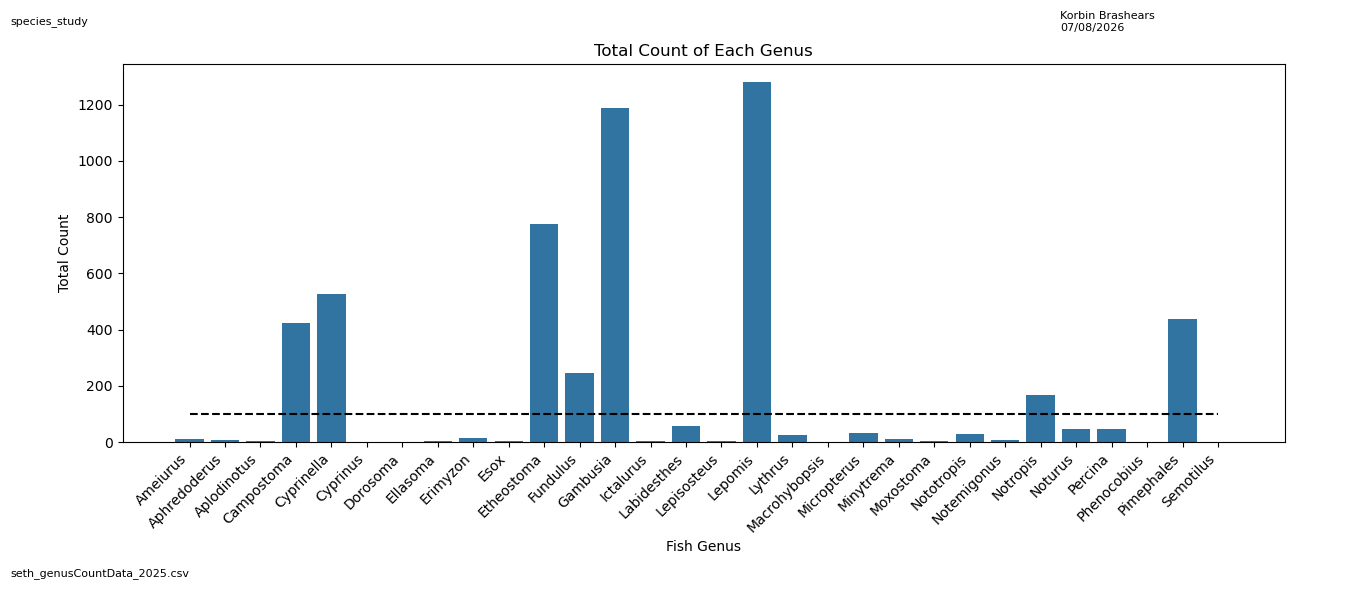

In [ ]:
# =================================================== Variable Definition =====================================================

genus_thresh = 100                                                      # Defining the genus population cutoff threshold.

# ===================================================== Data Analysis =========================================================

s_gcd_genus_cols = s_gcd.columns[1:31]                                  # Selecting the genus columns for summing.
genus_sum = s_gcd[s_gcd_genus_cols].sum()                               # Summing each genus column.

# ====================================================== Plotting =============================================================

plt.figure(figsize=(15, 6))                                             # Creating the figure for the bar plot with matplotlib.
sns.barplot(x=genus_sum.index, y=genus_sum.values)                      # Creating the bar plot with seaborn.
plt.plot(range(0,len(genus_sum)), 
         np.ones(len(genus_sum)) * genus_thresh,                        # Plotting the genus_thresh cutoff line.
         color='black', linestyle="--")      
plt.xticks(rotation=45, ha='right')                                     # Rotating x-axis labels for better readability and aligning them to the right.
plt.xlabel('Fish Genus')                                                # Setting x-axis label.
plt.ylabel('Total Count')                                               # Setting y-axis label.
plt.title('Total Count of Each Genus')                                  # Labeling the plot.

lpe(                                      # Calling the lpe to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=filenames['s_gcd'], 
    fig_filename="../figures/species_study/genus_barPlot.png",
    save = False                                                        # Change False to True to save the figure.
    )  

plt.show()                                                              # Displaying the plot inline.

> From this we can select only the genus where there is enough fish in out dataset to be relevant to our research.
>
> We set genus_thresh to 100 to filter out all genus less than Notropis, at 167.


> Creating a Data Frame of only the Genus that pass our threshold and their count.

In [159]:
genus_sum_df = genus_sum.to_frame(name='Count').T               # Converting our genus_sum from a list to a data frame and transposing it for easy column filtering.

rel_genus_cols = [gen for gen in genus_sum_df.columns if genus_sum_df[gen].iloc[0] >= genus_thresh]         # Filtering genus columns by genus_thresh.
rel_genus_df = genus_sum_df[rel_genus_cols].T                   # Using the filtered genus columns to select the correct columns from our genus_sum_df and transposing.

print(rel_genus_df)                                             # Printing our new relevant genus data frame to see our selected genus.

            Count
Campostoma    424
Cyprinella    525
Etheostoma    777
Fundulus      247
Gambusia     1190
Lepomis      1281
Notropis      167
Pimephales    439


<hr/>
<br/>


> Now we can repeat the same process to the Species within these Genus.

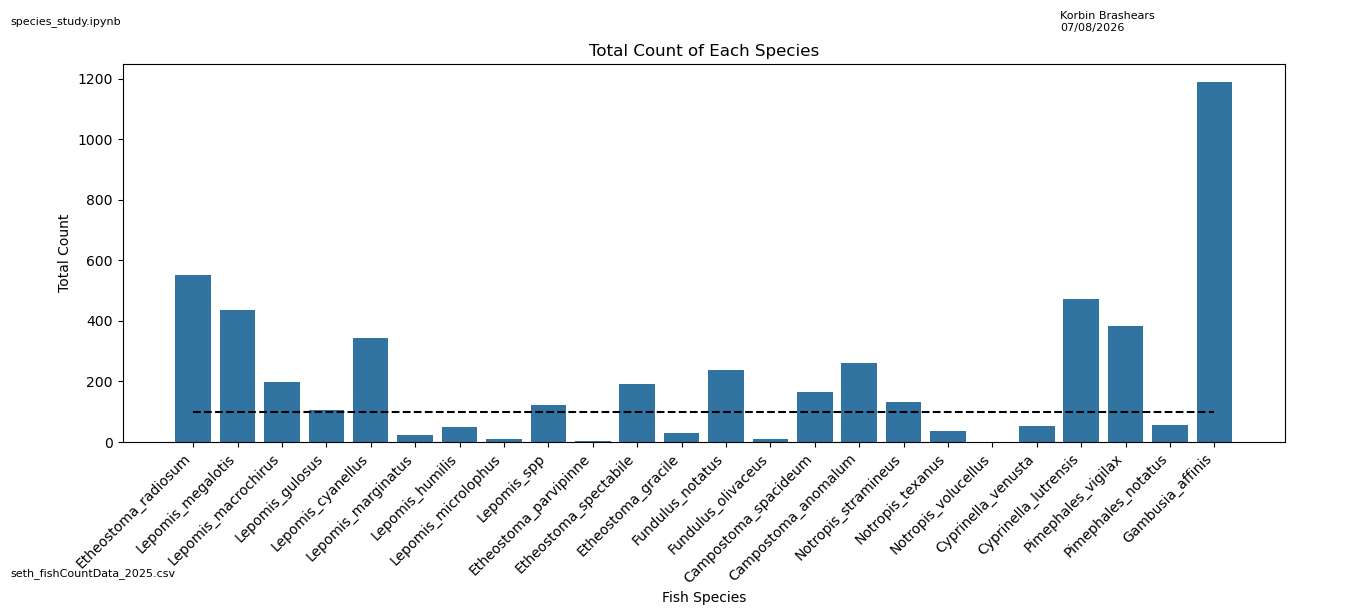

In [160]:
# =================================================== Variable Definition =====================================================

species_thresh = 100                                                    # Defining the species population cutoff threshold.

# ================================================== Data Analysis =========================================================

rel_species_cols = [spec for spec in s_fcd.columns if spec.split("_")[0] in rel_genus_cols]

species_sum = s_fcd[rel_species_cols].sum()                             # Summing each species column.

# ====================================================== Plotting ==========================================================

plt.figure(figsize=(15, 6))                                             # Creating the figure for the bar plot with matplotlib.
sns.barplot(x=species_sum.index, y=species_sum.values)                  # Creating the bar plot with seaborn.
plt.plot(range(0,len(species_sum)), 
         np.ones(len(species_sum)) * species_thresh,                    # Plotting the species_thresh cutoff line.
         color='black', linestyle="--")                                 
plt.xticks(rotation=45, ha='right')                                     # rotating x-axis labels for better readability and aligning them to the right.
plt.xlabel('Fish Species')                                              # Setting x-axis label.
plt.ylabel('Total Count')                                               # Setting y-axis label.
plt.title('Total Count of Each Species')                                # Labeling the plot.

lpe(                                  # Calling the lpe to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=filenames['s_fcd'], 
    fig_filename="../figures/species_study/species_barPlot.png",
    save = False                                                        # Change False to True to save the figure.
    )  

plt.show()                                                              # Displaying the plot.


> Creating a Data Frame of only the Species that pass our threshold and their count.

In [161]:
species_sum_df = species_sum.to_frame(name='Count').T               # Converting our species_sum from a list to a data frame and transposing it for easy column filtering.

rel_species_cols = [gen for gen in species_sum_df.columns if species_sum_df[gen].iloc[0] >= species_thresh]         # Filtering species columns by species_thresh.
rel_species_df = species_sum_df[rel_species_cols].T                   # Using the filtered species columns to select the correct columns from our species_sum_df and transposing.

print(rel_species_df)                                             # Printing our new relevant species data frame to see our selected species.

                       Count
Etheostoma_radiosum      550
Lepomis_megalotis        435
Lepomis_macrochirus      198
Lepomis_gulosus          104
Lepomis_cyanellus        342
Lepomis_spp              122
Etheostoma_spectabile    190
Fundulus_notatus         237
Campostoma_spacideum     163
Campostoma_anomalum      261
Notropis_stramineus      132
Cyprinella_lutrensis     472
Pimephales_vigilax       384
Gambusia_affinis        1190


<hr/>
<br/>

> Plotting the final species we are using in descending order.

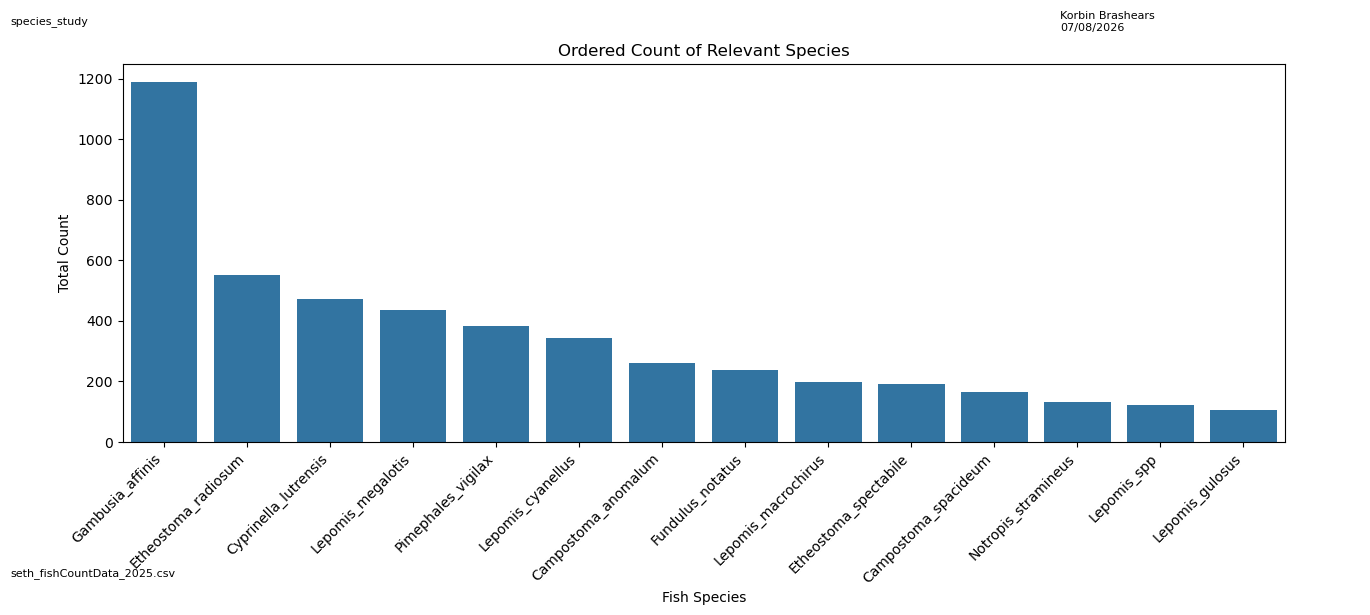

In [162]:
# ================================================== Data Analysis =========================================================

rel_species_df_ordered = rel_species_df.sort_values(by="Count", ascending=False)    # Ordering our relevant species data dataframe

# ====================================================== Plotting ==========================================================

plt.figure(figsize=(15, 6))                                             # Creating the figure for the bar plot with matplotlib.
sns.barplot(data=rel_species_df_ordered, 
            x=rel_species_df_ordered.index, 
            y="Count")                                                  # Creating the bar plot with seaborn.                
plt.xticks(rotation=45, ha='right')                                     # Rotating x-axis labels for better readability and aligning them to the right.
plt.xlabel('Fish Species')                                              # Setting x-axis label.
plt.ylabel('Total Count')                                               # Setting y-axis label.
plt.title('Ordered Count of Relevant Species')                          # Labeling the plot.

lpe(
    program_names="species_study",                                        # Calling the function to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=filenames['s_fcd'], 
    fig_filename="../figures/species_study/genus_study_ordered_species_barPlot.png",
    save = False                                                        # Change False to True to save individual figure.
    )  

plt.show()                                                              # Displaying the plot.

## <a id='toc1_3_'></a>[Relevant Species Summary](#toc0_)

> Now that we have out list of Species we want to focus our study on, we will do a deeper dive into each one.

> **Relevant Genus and Species list:**
>
> **Campostoma:**
>
> Campostoma_spacideum     
> Campostoma_anomalum
>
> **Cyprinella:**
>
> Cyprinella_lutrensis
>
> **Etheostoma:**
>
> Etheostoma_radiosum <br>
> Etheostoma_spectabile
>
> **Fundulus:**
>
> Fundulus_notatus
>
> **Gambusia:**
>
> Gambusia_affinis
>
> **Lepomis:**
>
> Lepomis_megalotis        
> Lepomis_macrochirus      
> Lepomis_gulosus          
> Lepomis_cyanellus        
> Lepomis_spp
>
> **Notropis:**
>
> Notropis_stramineus
>
> **Pimephales:**
>
> Pimephales_vigilax

### <a id='toc1_3_1_'></a>[Campostoma](#toc0_)

<h5>Campostoma anomalum (Central Stoneroller)</h5>

>**Eating Habits & Prey:** Primary herbivore. It acts as a stream "lawnmower," using a specialized, razor-sharp cartilaginous ridge on its lower jaw to scrape benthic algae, detritus, and diatoms off stones.
>
>**Migration & Other Habits:** Schooling, highly active, and non-migratory. It forms large grazing herds that move dynamically between riffles and pools.
>
>**Likes & Dislikes:** Likes rocky riffles with moderate to fast currents and high sunlight to fuel algae growth. Dislikes uniform sand or mud channels lacking hard structures.
>
>**Body Features:** Torpedo-shaped, brownish-tan body. It features an unusually long intestine wrapped completely around its swim bladder to aid in digesting tough plant matter.
>
>**Size Range (Weight):** Min: 0.01 lbs | Max: 0.22 lbs | Median: 0.07 lbs
>
>**Predators:** Largemouth bass, smallmouth bass, spotted bass, and larger sunfish species.
>
>**Ecological Concerns:** Secure and stable; they are critical for maintaining overall stream health by controlling nuisance algae blooms.
>
>**Species vs. Genus Notables:** It is globally widespread across North America, serving as the baseline ecological model for primary consumers within the genus, whereas its sister species are often highly localized geographic specialists.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Campostoma_anomalum.jpg" alt="Campostoma Anomalum" style="height:300px; width:auto; border: 2px, solid;">
</div>

<h5>Campostoma spadiceum (Highland Stoneroller)</h5>

>**Eating Habits & Prey:** Herbivorous algivore. It targets periphyton, diatoms, and filamentous algae attached to hard river substrates.
>
>**Migration & Other Habits:** Schooling fish and non-migratory. Breeding males exhibit unique engineering behavior, using their heads to physically roll pebbles and dig out nesting trenches.
>
>**Likes & Dislikes:** Likes clear, cool, flowing upland streams with rocky or gravel substrates exposed to bright sunlight. Dislikes deep mud, heavy bank shade, and stagnant water.
>
>**Body Features:** Stout, cylindrical body. Breeding males develop vivid, fiery-red or orange fins year-round, a vertical black bar at the base of the tail, and hard, horn-like breeding tubercles on their heads.
>
>**Size Range (Weight):** Min: 0.01 lbs | Max: 0.18 lbs | Median: 0.06 lbs
>
>**Predators:** Centrachids, particularly bass, larger sunfish, and wading birds like herons.
>
>**Ecological Concerns:** Highly vulnerable to flash droughts and severe sedimentation that buries the clean rocky substrates required for feeding and nesting.
>
>**Species vs. Genus Notables:** Formally described as a distinct species in 2010, it differs from other stonerollers by maintaining its bright red fin pigmentation year-round and having a restricted range endemic to the Interior Highlands.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/campostoma_spadiceum.jpg" alt="Campostoma Spadiceum" style="height:300px; width:auto; border: 2px, solid;">
</div>

### <a id='toc1_3_2_'></a>[Cyprinella](#toc0_)

<h5>Cyprinella lutrensis (Red Shiner)</h5>

>**Eating Habits & Prey:** Opportunistic omnivore. It feeds on aquatic insect larvae, terrestrial insects that fall into the water, algae, and occasionally the eggs or fry of competing fish species.
>
>**Migration & Other Habits:** Highly adaptable schooler and non-migratory. It broadcasts eggs over any available surface, including submerged roots, aquatic vegetation, or old nests of larger fish.
>
>**Likes & Dislikes:** Likes slow-moving pools, backwaters, and muddy, turbid channels. Dislikes pristine, cold, high-velocity mountain torrents.
>
>**Body Features:** Deep, highly compressed, diamond-shaped body. Breeding males turn a striking metallic blue with bright red-orange fins and a red crown.
>
>**Size Range (Weight):** Min: 0.002 lbs | Max: 0.015 lbs | Median: 0.005 lbs
>
>**Predators:** Channel catfish, flathead catfish, largemouth bass, gar, and herons.
>
>**Ecological Concerns:** Highly secure; its extreme resilience to poor water quality makes it a problematic invasive threat when introduced outside its native range.
>
>**Species vs. Genus Notables:** It is the most pollution-, silt-, and drought-tolerant member of the Cyprinella genus, making it exceptionally successful in heavily modified agricultural streams across Texas.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Cyprinella_lutrensis.jpg" alt="Cyprinella Lutrensis" style="height:300px; width:auto; border: 2px, solid;">
</div>

### <a id='toc1_3_3_'></a>[Etheostoma](#toc0_)

<h5>Etheostoma radiosum (Orangebelly Darter)</h5>

>**Eating Habits & Prey:** Specialized invertivore. It targets benthic aquatic insect larvae, primarily midges (Chironomidae), mayflies (Ephemeroptera), and caddisflies (Trichoptera).
>
>**Migration & Other Habits:** Strictly non-migratory. It remains in its localized stream reach. It spawns in early spring, depositing eggs directly into coarse gravel.
>
>**Likes & Dislikes:** Likes cool, clear headwaters and small streams with swift current velocities and gravel/rubble bottoms. Dislikes stagnant pools, high turbidity, and heavy mud or silt sedimentation.
>
>**Body Features:** Small, slender body with a blunt head and no swim bladder, keeping it tethered to the stream bottom. Breeding males display vibrant orange-red bellies and blue-green bands on their fins.
>
>**Size Range (Weight):** Min: 0.002 lbs | Max: 0.011 lbs | Median: 0.005 lbs
>
>**Predators:** Juvenile bass (Micropterus), larger sunfish (Lepomis), and wading birds.
>
>**Ecological Concerns:** Highly vulnerable to stream fragmentation (dams/culverts) and excessive siltation from land clearing, which smothers its gravel spawning beds.
>
>**Species vs. Genus Notables:** While the genus Etheostoma contains over 150 species across North America, E. radiosum has a highly localized geographic footprint, endemic primarily to the Red and Ouachita River drainages.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Etheostoma_radiosum.jpg" alt="Etheostoma Radiosum" style="height:300px; width:auto; border: 2px, solid;">
</div>

<h5>Etheostoma spectabile (Orangethroat Darter)</h5>

>**Eating Habits & Prey:** Benthic invertivore. It feeds on blackfly larvae, midge larvae, caddisfly larvae, and tiny amphipods within the rocky substrate.
>
>**Migration & Other Habits:** Non-migratory. Spawns in extremely shallow riffles during spring, burying its adhesive eggs in fine gravel beds.
>
>**Likes & Dislikes:** Likes small, shallow, sunlit creeks with moderate flow and mixed gravel/slab rock bottoms. Dislikes deep, muddy, or heavily choked slow rivers.
>
>**Body Features:** Small, colorful body. Breeding males develop a brilliant orange-red throat and branchiostegal membranes, with alternating blue and orange vertical bars down their sides.
>
>**Size Range (Weight):** Min: 0.002 lbs | Max: 0.010 lbs | Median: 0.004 lbs
>
>**Predators:** Sunfish, juvenile bass, and large predatory crayfish.
>
>**Ecological Concerns:** Vulnerable to urban and agricultural runoff; severe siltation glues gravel together, ruining its nesting and feeding spots.
>
>**Species vs. Genus Notables:** Compared to the highly sensitive E. radiosum, E. spectabile is noticeably more tolerant of intermittent flows and slight turbidity, enabling it to survive in smaller prairie streams.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Etheostoma_spectabile.jpg" alt="Etheostoma Spectabile" style="height:300px; width:auto; border: 2px, solid;">
</div>

### <a id='toc1_3_4_'></a>[Fundulus](#toc0_)

<h5>Fundulus notatus (Blackstripe Topminnow)</h5>

>**Eating Habits & Prey:** Specialized surface feeder (invertivore). It eats terrestrial insects that fall into the water, mosquito larvae, and surface-skimming microcrustaceans.
>
>**Migration & Other Habits:** Non-migratory. It spends its life within the top two inches of the water column, laying eggs individually on submerged aquatic plants.
>
>**Likes & Dislikes:** Likes calm, slow-moving, or stagnant pools, sloughs, and stream margins with overhanging riparian vegetation. Dislikes swift currents and wide, open, deep water.
>
>**Body Features:** Slender, cigar-shaped body with a flattened head and an upturned (superior) mouth. A prominent, continuous black stripe runs from the tip of the snout to the tail.
>
>**Size Range (Weight):** Min: 0.003 lbs | Max: 0.014 lbs | Median: 0.006 lbs
>
>**Predators:** Sunfish, bass, kingfishers, and water snakes.
>
>**Ecological Concerns:** Secure, but highly dependent on healthy stream banks; removal of riparian trees directly destroys their shade and feeding zones.
>
>**Species vs. Genus Notables:** While most members of the Fundulus genus are coastal, estuarine, or salt-marsh specialists, F. notatus is uniquely adapted strictly to inland freshwater streams.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Fundulus_notatus.jpg" alt="Fundulus Notatus" style="height:300px; width:auto; border: 2px, solid;">
</div>

### <a id='toc1_3_5_'></a>[Gambusia](#toc0_)

<h5>Gambusia affinis (Western Mosquitofish)</h5>

>**Eating Habits & Prey:** Surface insectivore. It is highly specialized in consuming mosquito larvae, alongside zooplankton and small surface-drifting insects.
>
>**Migration & Other Habits:** Surface-oriented schooler. Livebearer (viviparous)—females give birth to fully formed, swimming young rather than laying eggs, allowing rapid population explosions.
>
>**Likes & Dislikes:** Likes hot, completely stagnant, shallow shorelines and heavily weeded ponds. Dislikes fast, turbulent currents and cold water temperatures.
>
>**Body Features:** Tiny size, upturned mouth, and a rounded tail. Females are twice the size of males and display a dark, visible gravid spot near the vent when pregnant.
>
>**Size Range (Weight):** Min: 0.001 lbs | Max: 0.005 lbs | Median: 0.003 lbs
>
>**Predators:** Sunfish, juvenile bass, water snakes, and large predatory aquatic insects like diving beetles.
>
>**Ecological Concerns:** Secure. Highly invasive globally due to widespread stocking for mosquito control, though it is native to your East Texas study region.
>
>**Species vs. Genus Notables:** The definitive representative of the Gambusia genus, its live-bearing reproductive strategy is an evolutionary masterstroke for intermittent Texas creeks, completely bypassing the risk of eggs drying out or suffocating in mud during seasonal droughts.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Gambusia_affinis.jpg" alt="Gambusia Affinis" style="height:300px; width:auto; border: 2px, solid;">
</div>

### <a id='toc1_3_6_'></a>[Lepomis](#toc0_)

<h5>Lepomis cyanellus (Green Sunfish)</h5>

>**Eating Habits & Prey:** Aggressive, highly voracious carnivore. It eats anything it can fit in its mouth, including insects, crayfish, and smaller minnows.
>
>**Migration & Other Habits:** Exceptional pioneer species. It does not migrate long distances but quickly redistributes up dry creeks as soon as wet-season flows return.
>
>**Likes & Dislikes:** Tolerates almost anything. Likes small, stagnant pools and muddy ditches. Dislikes high-gradient, fast-flowing mountain streams.
>
>**Body Features:** More elongated and less deep-bodied than other sunfish. It has a large mouth, electric-blue flecks on its cheeks, and bright yellow margins on its dorsal and anal fins.
>
>**Size Range (Weight):** Min: 0.05 lbs | Max: 2.20 lbs | Median: 0.35 lbs
>
>**Predators:** Largemouth bass, flathead catfish, wading birds, and water snakes.
>
>**Ecological Concerns:** Secure; its extreme hardiness allows it to become an aggressive invasive risk when introduced outside its native basins.
>
>**Species vs. Genus Notables:** It is the most environmental-stress-tolerant member of the Lepomis genus, capable of surviving severe drought pools with low dissolved oxygen (DO) that kill all other sunfish.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Lepomis_cyanellus.jpg" alt="Lepomis Cyanellus" style="height:300px; width:auto; border: 2px, solid;">
</div>

<h5>Lepomis gulosus (Warmouth)</h5>

>**Eating Habits & Prey:** Cryptic carnivore. It specializes in larger prey than most sunfish, actively hunting crayfish, minnows, and large dragonfly nymphs.
>
>**Migration & Other Habits:** Solitary and highly nocturnal or crepuscular. Non-migratory.
>
>**Likes & Dislikes:** Likes heavily vegetated, murky, low-flow pools, swamps, and bayous with soft organic debris or mud bottoms. Dislikes clear, fast-flowing gravel riffles.
>
>**Body Features:** Thick, robust body with a disproportionately large mouth (resembling a bass) and three to four dark stripes radiating backward from a red-ringed eye.
>
>**Size Range (Weight):** Min: 0.05 lbs | Max: 2.40 lbs | Median: 0.45 lbs
>
>**Predators:** Large bass, flathead catfish, and alligators.
>
>**Ecological Concerns:** Secure; exceptionally tolerant of hypoxic (low dissolved oxygen) environments and high water temperatures.
>
>**Species vs. Genus Notables:** Unlike the rest of the small-mouthed Lepomis genus, the Warmouth possesses an enlarged gape and a patch of small teeth on its tongue, making it ecologically behave more like a black bass.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Lepomis_gulosus.jpg" alt="Lepomis Gulosus" style="height:300px; width:auto; border: 2px, solid;">
</div>

<h5>Lepomis macrochirus (Bluegill)</h5>

>**Eating Habits & Prey:** Generalist omnivore/invertivore. It consumes zooplankton, aquatic insect larvae, snails, worms, and small amounts of filamentous algae.
>
>**Migration & Other Habits:** Non-migratory. It forms dense schools and participates in synchronized colonial nesting where dozens of males pack nests closely together.
>
>**Likes & Dislikes:** Likes warm, quiet, well-vegetated pools, backwaters, and littoral zones. Dislikes high-velocity channels and completely bare, structured-less sand beds.
>
>**Body Features:** Deep, slab-sided body. It exhibits a dark spot at the posterior base of the soft dorsal fin and a solid black ear flap without light borders.
>
>**Size Range (Weight):** Min: 0.05 lbs | Max: 4.75 lbs | Median: 0.55 lbs
>
>**Predators:** Largemouth bass, longnose gar, snapping turtles, and blue herons.
>
>**Ecological Concerns:** Secure; often overpopulates and stunts in size if top-tier apex predators are removed from a stream system.
>
>**Species vs. Genus Notables:** It is the quintessential generalist of the Lepomis genus, possessing finer gill rakers than its peers, which allows it to filter tiny zooplankton far more efficiently than other sunfish.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Lepomis_macrochirus.jpg" alt="Lepomis Macrochirus" style="height:300px; width:auto; border: 2px, solid;">
</div>

<h5>Lepomis megalotis (Longear Sunfish)</h5>

>**Eating Habits & Prey:** Opportunistic invertivore and carnivore. It feeds on aquatic insects, small crustaceans, surface-drifted terrestrial insects, and small fish fry.
>
>**Migration & Other Habits:** Non-migratory. Males are highly territorial and colonial nesters, digging shallow, circular gravel depressions in bright sunlight.
>
>**Likes & Dislikes:** Likes clear, slow-moving streams, pools with physical structures (boulders, root wads, brush piles), and warm water. Dislikes swift currents, heavy mud bottoms, and deep shade.
>
>**Body Features:** Deep, laterally compressed body. It features a remarkably long, flexible, entirely black opercular (ear) flap bordered neatly in white or light blue.
>
>**Size Range (Weight):** Min: 0.04 lbs | Max: 1.74 lbs | Median: 0.25 lbs
>
>**Predators:** Largemouth bass, flathead catfish, herons, and otters.
>
>**Ecological Concerns:** Least concern; highly secure and adaptable.
>
>**Species vs. Genus Notables:** It stands out from the rest of the Lepomis genus due to its extreme, neon-bright blue and orange coloration and its elongated ear flap, making it far more colorful than close relatives like the Bluegill.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Lepomis_megalotis.jpg" alt="Lepomis Megalotis" style="height:300px; width:auto; border: 2px, solid;">
</div>

<h5>Lepomis spp (Unclassified Sunfish)</h5>

>**Eating Habits & Prey:** Generalist carnivores and invertivores. They consume a mix of aquatic insects, microcrustaceans, small fish, and surface drift depending on exact species composition.
>
>**Migration & Other Habits:** Primarily non-migratory, pool-dwelling fish. They display territorial nesting traits, with males fanning out depressions in sand or gravel substrates during late spring.
>
>**Likes & Dislikes:** Like slow-moving water, structural cover (woody debris, boulders), and warm stream temperatures. Dislike high-velocity channels and heavy siltation that ruins nesting beds.
>
>**Body Features:** Deep, laterally compressed bodies with spiny dorsal fins. This designation captures juvenile, hybrid, or unclassified sunfish specimens displaying intermediate traits.
>
>**Size Range (Weight):** Min: 0.04 lbs | Max: 3.00 lbs | Median: 0.35 lbs
>
>**Predators:** Larger black bass, catfish, wading birds, and water snakes.
>
>**Ecological Concerns:** Secure overall, though individual cryptic species or hybrids within the complex can reflect localized habitat degradation or displacement.
>
>**Species vs. Genus Notables:** Represents the collective ecological baseline of the genus Lepomis in Texas streams, capturing wide hybridization tendencies and multi-species visual overlaps in field surveys.

<div style="display: flex; justify-content: center;">
    <p style="font-weight: 800; text-align: center; border: 2px, solid; padding: 20px;">
        There is no image for this classification as Spp simply refers to a multitude of plural species that could not or were not identified as a specific species.
    </p>
</div>

### <a id='toc1_3_7_'></a>[Notropis](#toc0_)

<h5>Notropis stramineus (Sand Shiner)</h5>

>**Eating Habits & Prey:** Generalist omnivore and detritivore. It eats small aquatic insects, terrestrial drift, algae, and organic bottom ooze.
>
>**Migration & Other Habits:** Schooling minnow and non-migratory. It broadcasts its adhesive eggs over open sand and gravel bars.
>
>**Likes & Dislikes:** Likes open, shallow, flowing prairie streams with loose, sandy or fine gravel bottoms. Dislikes dense aquatic weed beds and stagnant mud pools.
>
>**Body Features:** Small, translucent, silver-straw colored body with a dark stripe down the spine and a distinct line of dark dashes tracking its lateral line.
>
>**Size Range (Weight):** Min: 0.002 lbs | Max: 0.012 lbs | Median: 0.005 lbs
>
>**Predators:** Bass, sunfish, longnose gar, and terns.
>
>**Ecological Concerns:** Stable, but threatened by river channelization and upstream dams that stop the natural downstream transport of sand.
>
>**Species vs. Genus Notables:** The genus Notropis is vast and complex. N. stramineus is unique because it specializes in unstable, shifting sandy bottom habitats where most other shiners cannot successfully forage or spawn.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Notropis_stramineus.jpg" alt="Notropis Stramineus" style="height:300px; width:auto; border: 2px, solid;">
</div>

### <a id='toc1_3_8_'></a>[Pimephales](#toc0_)

<h5>Pimephales vigilax (Bullhead Minnow)</h5>

>**Eating Habits & Prey:** Benthic omnivore and detritivore. It consumes bottom detritus, organic mud, diatoms, and tiny midge larvae.
>
>**Migration & Other Habits:** Schooling minnow. It exhibits advanced parental care: males choose the underside of flat rocks or logs, clean the surface, and aggressively guard the eggs.
>
>**Likes & Dislikes:** Likes sluggish pools, slow runs, and large river backwaters with sand, silt, or mud bottoms. Dislikes cold, fast-flowing, high-gradient mountain streams.
>
>**Body Features:** Blunt, rounded head with a heavy, pad-like snout. It has a dull silvery-tan body with a prominent black spot at the front base of the dorsal fin and another at the tail base.
>
>**Size Range (Weight):** Min: 0.002 lbs | Max: 0.016 lbs | Median: 0.006 lbs
>
>**Predators:** Immature catfish, bass, and wading birds.
>
>**Ecological Concerns:** Secure; handles agricultural runoff and high turbidity very well.
>
>**Species vs. Genus Notables:** During the breeding season, males develop a distinctive, thickened fleshy pad on the top of their head (more pronounced than in the related Fathead Minnow) used to physically clean and prep the underside of nesting rocks.

<div style="display: flex; justify-content: center;">
    <img src="../figures/rel_species_images/Pimephales_vigilax.jpg" alt="Pimephales Vigilax" style="height:300px; width:auto; border: 2px, solid, black;">
</div>


## <a id='toc1_4_'></a>[Driver Analysis And Prediction Models](#toc0_)

<h3>Analysis Objectives & Methodological Framework</h3>

>**Using Fish Traits to Find Key Drivers:** 
Our main goal is to use the eating habits, body features, and preferences of each fish to understand why populations change. By connecting these traits directly to our stream data and climate data, we can figure out exactly what causes certain fish to thrive or disappear at different locations.

>**Testing Known Behaviors with Visuals:** 
We will use data charts and graphs to test if the fish are behaving the way textbooks say they should. For example, we can plot fish counts against mud levels (`pb_Mud`) or water depth (`avg_Depth`) to see if the field data actually backs up their known preferences.

>**Finding New Patterns & Climate Impacts:** 
Beyond testing what we already know, we want to look for surprising patterns or unusual fish behavior. By combining our local stream data with the 24-year satellite data analysis, from *time_series_analysis_2026.ipynb*, we can see how long-term problems—like repeated droughts (`palmer_z`) or fires—cause unexpected damage to the fish communities over time.

>**Building Predictive Models:** 
Finally, we will use everything we learn to build smart computer models. By knowing exactly which stream conditions and weather patterns matter most to each fish, we can create accurate models to predict where species will be present, where they will be absent, and which areas are at risk of a population crash.

<hr/>



### <a id='toc1_4_1_'></a>[Campostoma](#toc0_)

<h3>Campostoma anomalum</h3>

<h4>Expectations & Hypotheses</h4>

>**Known Behavior & Expectations:**
* **Benthic Algae Scraping:** They use a hard jaw ridge to eat algae off rocks. We can test this by looking for higher fish counts in shallow areas with high sunlight exposure, which fuels algae growth.
* **Riffle & Substrate Dependence:** They require clean rocks to feed and roll pebbles for nests. We can test if they actively avoid muddy bottoms and prefer areas with fast-moving, shallow water over gravel.
* **Flow & Weather Sensitivity:** They live in shallow habitats that dry out quickly. We can test if their populations drop at sites with low minimum stream flows or extended periods of high summer heat.
* **Community Schooling:** They move in large grazing herds. We can test this by checking if their presence overlaps with other small, rock-dwelling species or if they are excluded from deep water by larger predators.

>**Hypotheses:**
* **Food & Habitat Availability:** Fish counts will show a strong upward curve in shallow, rocky stream runs, but will flatline or drop to zero as the stream bottom switches from gravel to thick mud where algae cannot grow.
* **Drought & Flow Dynamics:** Extended regional droughts and highly unstable, flashy stream flows will trigger severe population crashes by drying out shallow riffle zones and trapping fish in stagnant pools.
* **Farming & Siltation Stress:** High agricultural land use upstream will negatively impact fish counts because soil erosion creates muddy bottoms that bury rocky feeding grounds and cause dangerous drops in dissolved oxygen.
* **Predator & Cohabitant Relationships:** Stoneroller populations will positively overlap with small benthic darters that share the same rocky riffles due to shared habitat needs, but will be absent from deep pools with high predator counts.

>**Expected Drivers We Will Observe:**
* **Food & Habitat Metrics:** Strong positive correlations with rocky bottom types (`pb_SmGravel`, `pb_LgGravel`, `pb_Cobble`) and fast stream sections (`pf_Run`, `pf_Riffle`). Strong negative correlations with deep pools (`avg_Depth`, `pf_Pool`) and mud (`pb_Mud`).
* **Drought & Flow Metrics:** Sharp population drops when long-term drought indices (`palmer_z`, `palmer_p`) stay negative, when summer heatwaves (`maxT`) spike in the time series, or when minimum flows (`minMonthFlow_cfs`) approach zero. High flow variability (`CV_flow`) will also lower presence.
* **Farming & Siltation Metrics:** A clear drop-off in fish counts at sites where upstream farming signals (`alfalfa`, `grass`) cause mud levels (`pb_Mud`) to rise and dissolved oxygen (`DO`) to fall.
* **Predator & Cohabitant Metrics:** High positive spatial overlap with *Etheostoma* species counts, and clear negative spatial relationships with larger predatory sunfish (`Lepomis_gulosus`) and bass (`Micropterus`).

<hr/>

> The Central Stoneroller (*Campostoma anomalum*) is an obligate benthic algivore, so its abundance is expected to depend heavily on clean, stable gravel substrates that support periphyton growth. Because benthic algae require both sunlight and sediment‑free surfaces, we expect C. anomalum to be strongly associated with riffles that receive high solar radiation.

> Due to its streamlined body and schooling behavior, C. anomalum prefers rocky riffle habitats over slow, depositional pools. Moderate to fast flow helps maintain these habitats by flushing fine sediments downstream, preventing the smothering of algal resources.

> During the breeding season, males excavate gravel to build communal spawning pits. For this reason, we expect the species to prefer small, movable gravel that can be manipulated during nest construction.

> As a small schooling species, C. anomalum is likely to avoid areas with high densities of larger predatory or aggressive fish (e.g., *Lepomis* spp.). We will test whether its abundance is inversely related to these larger competitors.

> Conversely, we expect positive associations with other small schooling minnows that share similar flow and habitat preferences.

> **From this we can assume their population will be related to the features as follows:**

* Positively related to **pb_SmGravel** (ideal substrate for algae and nest building).

* Inversely related to **pb_Mud**, **pb_Sand**, and **pb_Bedrock** (fine sediments smother algae; bedrock lacks loose gravel).

* Positively related to the various **sunshine** metrics (sunlight drives periphyton productivity).

* Inversely related to **pft_Macrophytes** (macrophytes shade the substrate and outcompete benthic algae).

* Possibly inversely related to **pft_Wood** (floating wood may block sunlight reaching the stream bed).

* **Flow habitat expectations:**  
  - Positively related to **pf_Riffle** (preferred high‑velocity, rocky habitat).  
  - Positively related to **pf_Pool** (may reflect transitional or mixed habitats where riffles and pools co‑occur).  
  - Inversely related to **pf_Run** (runs may represent more uniform, less structured habitat).  
  - However, because these flow metrics can be subjective or inconsistently interpreted in field surveys, **all three will be tested empirically**.

* Inversely related to **local agriculture** if a metric is available, due to siltation and turbidity degrading riffle habitats.

> Many of these are directional hypotheses based on ecological expectations; the dataset will ultimately determine which relationships hold true.

<hr/>

> **First we will simply create a correlation decay plot, with the following metrics, to get a general idea of our metrics' relation to C. Anomalum:**

* The environmental metrics
* The burn / condensed time series metrics
* The expected key drives / metrics of interest

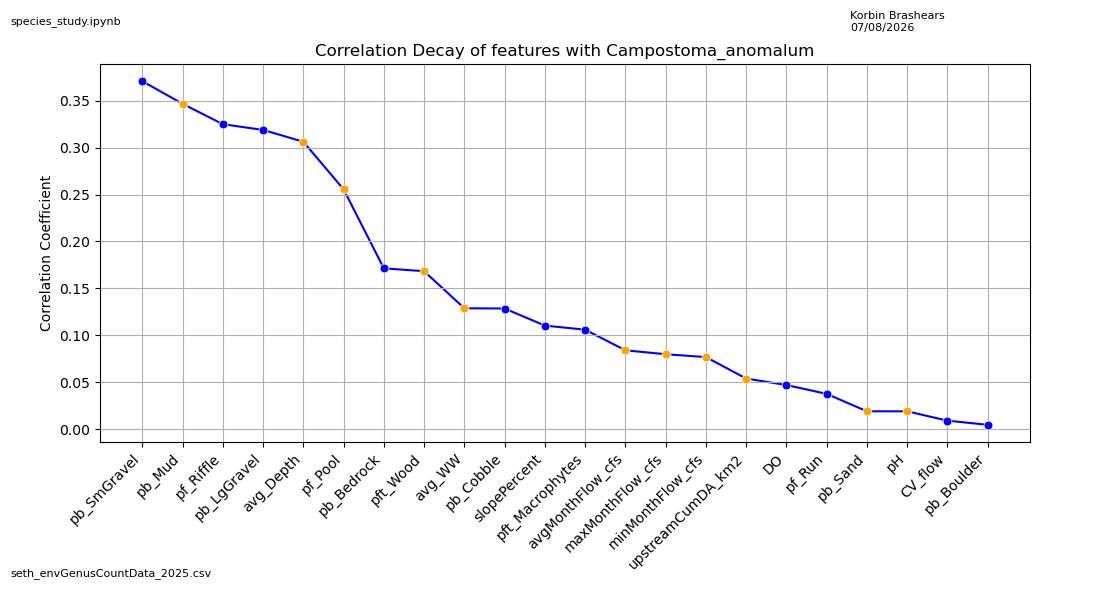

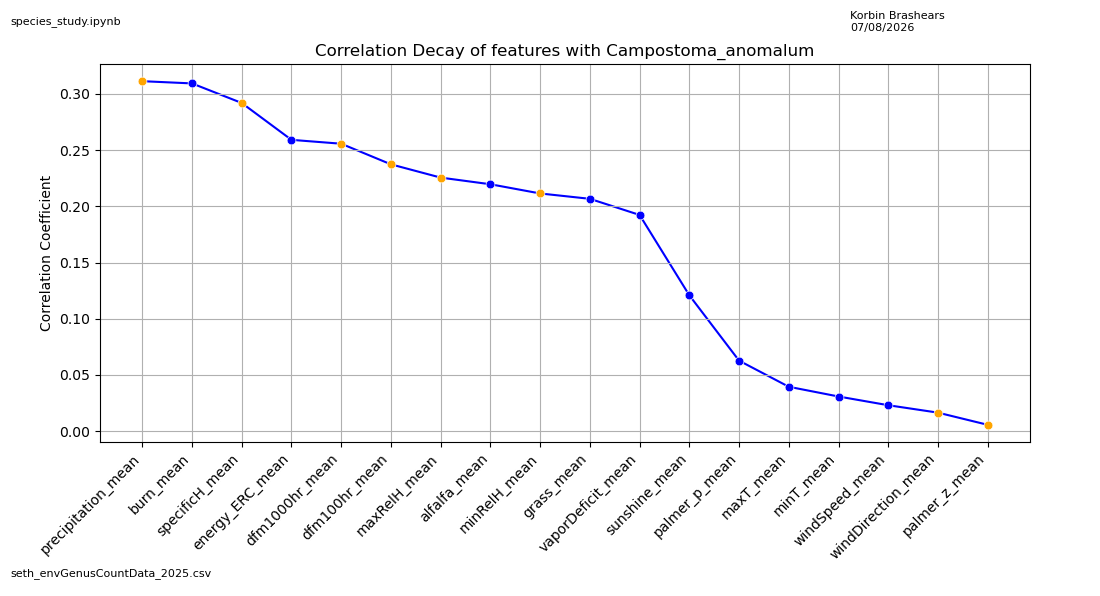

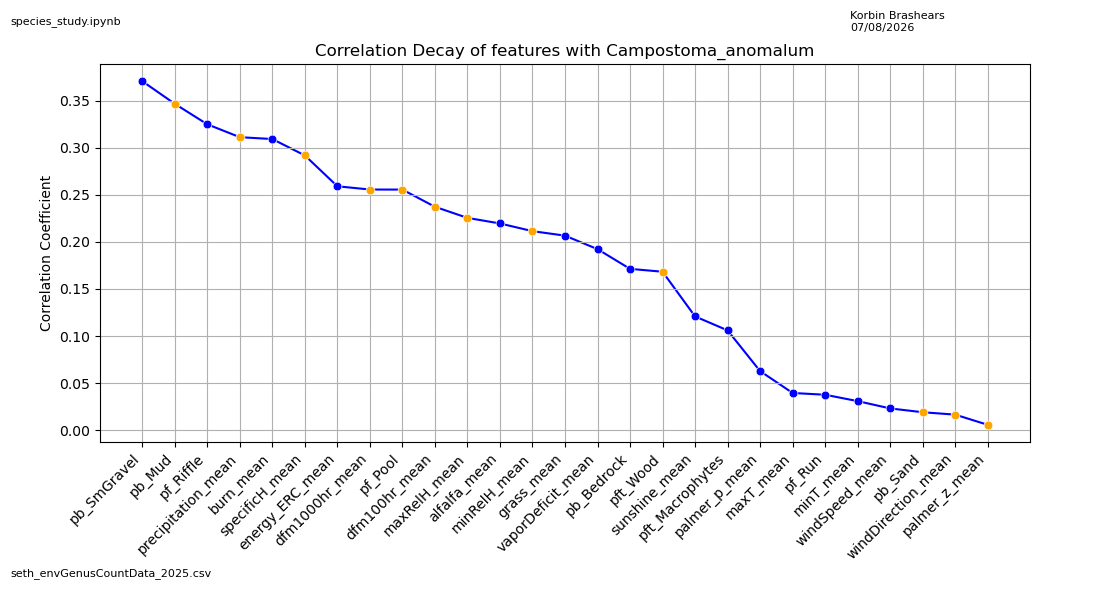

In [163]:
# All environmental metrics
env_m = s_ed.columns[1:]

# All burn metrics
burn_m = g_10dts_m.columns[1:]

# EKD environmental metrics (manually selected)
ekd_env_m = [
    "pb_SmGravel",
    "pb_Mud",
    "pb_Sand",
    "pb_Bedrock",
    "pft_Macrophytes",
    "pft_Wood",
    "pf_Riffle",
    "pf_Pool",
    "pf_Run"
]

# Suffixes we want to keep from burn metrics
ekd_suffixes = ["_mean"]

# Select only burn metrics ending with these suffixes
ekd_burn_m = [col for col in g_10dts_m.columns if any(col.endswith(suf) for suf in ekd_suffixes)]

# Combine into one EKD DataFrame
ekd_m = pd.concat([s_ed[ekd_env_m], g_10dts_m[ekd_burn_m]], axis=1)

# Run correlation-decay plots
corr_decay_plotter(attribute=s_fcd['Campostoma_anomalum'], features=s_ed[env_m])
corr_decay_plotter(attribute=s_fcd['Campostoma_anomalum'], features=g_10dts_m[ekd_burn_m])
corr_decay_plotter(attribute=s_fcd['Campostoma_anomalum'], features=ekd_m)


> **Next we will run a principle component analysis to the sites containing C. Anomalum to find out which metrics explain the most variance within those sites:**

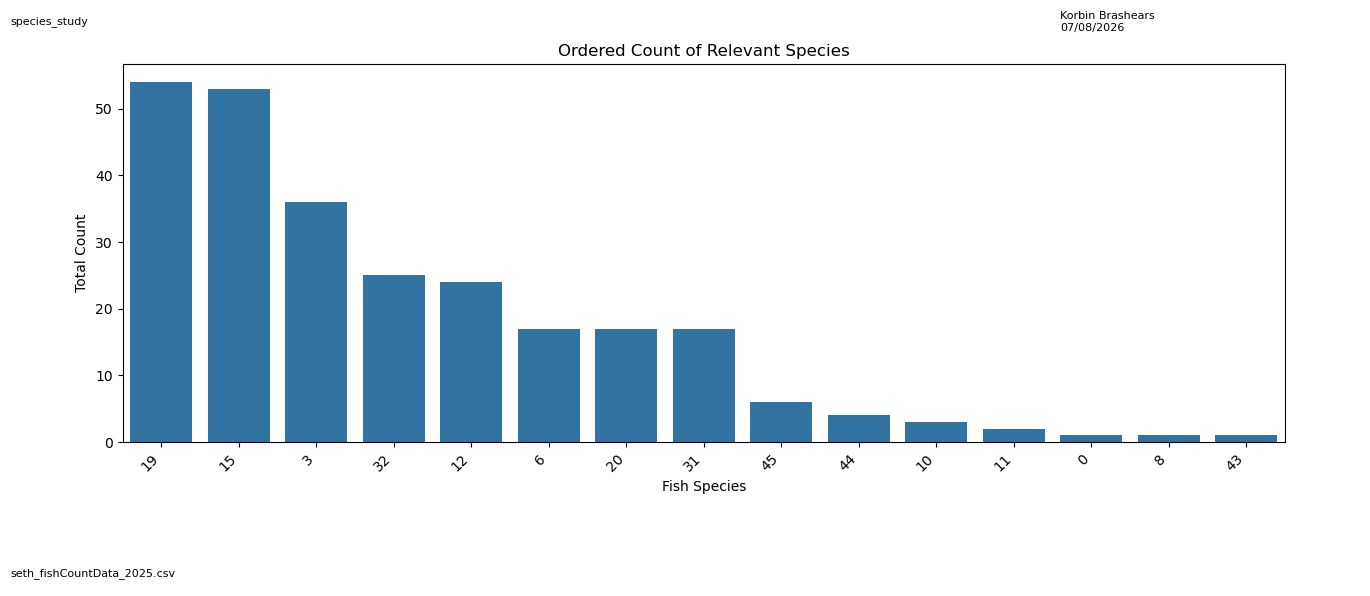

19    54
15    53
3     36
32    25
12    24
6     17
20    17
31    17
45     6
44     4
10     3
11     2
0      1
8      1
43     1
Name: Campostoma_anomalum, dtype: int64


In [164]:
c_anomalum_sites = s_fcd[s_fcd['Campostoma_anomalum'] > 0]

# ================================================== Data Analysis =========================================================

c_anomalum_sites_ordered = c_anomalum_sites.sort_values(by="Campostoma_anomalum", ascending=False)    # Ordering our relevant species data dataframe

# ====================================================== Plotting ==========================================================

plt.figure(figsize=(15, 6))                                             # Creating the figure for the bar plot with matplotlib.
sns.barplot(data=c_anomalum_sites_ordered, 
            x=c_anomalum_sites_ordered.index, 
            y="Campostoma_anomalum",
            order=c_anomalum_sites_ordered.index)                                                  # Creating the bar plot with seaborn.                
plt.xticks(rotation=45, ha='right')                                     # Rotating x-axis labels for better readability and aligning them to the right.
plt.xlabel('Fish Species')                                              # Setting x-axis label.
plt.ylabel('Total Count')                                               # Setting y-axis label.
plt.title('Ordered Count of Relevant Species')                          # Labeling the plot.

lpe(
    program_names="species_study",                                        # Calling the function to label the edges of the plot.
    author_names="Korbin Brashears", 
    data_filenames=filenames['s_fcd'], 
    fig_filename="../figures/species_study/genus_study_ordered_species_barPlot.png",
    save = False                                                        # Change False to True to save individual figure.
    )  

plt.show()                                                              # Displaying the plot.

print(c_anomalum_sites_ordered['Campostoma_anomalum'])

> Several sites contain fewer than 10 *Campostoma anomalum*.  
> Because this species is strongly schooling, such low counts are not ecologically representative.  
> For all PCA and niche‑space analyses, we therefore restrict to sites with **N > 10** individuals.

In [165]:
c_anomalum_sites = s_fcd[s_fcd['Campostoma_anomalum'] > 10]

print(c_anomalum_sites['Campostoma_anomalum'])

3     36
6     17
12    24
15    53
19    54
20    17
31    17
32    25
Name: Campostoma_anomalum, dtype: int64


In [166]:
# Extract the site indices
idx = c_anomalum_sites.index

# Filter environmental and burn metrics to these sites
env_filtered = s_ed.drop('SiteN', axis=1).loc[idx]
#burn_filtered = g_10dts_m.drop('SiteN', axis=1).loc[idx]

# Combine all environmental + burn metrics
metrics_all = s_ed.drop('SiteN', axis=1)
metrics_filtered = env_filtered

# Combine all environmental + burn metrics
# metrics_all = pd.concat([s_ed.drop('SiteN', axis=1), g_10dts_m.drop('SiteN', axis=1)], axis=1)
# metrics_filtered = pd.concat([env_filtered, burn_filtered], axis=1)

In [167]:
def pca_decay_plotter(features, title_prefix="", save=False):
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)

    # PCA
    pca = PCA()
    pca.fit(X_scaled)

    explained = pca.explained_variance_ratio_
    components = np.arange(1, len(explained) + 1)

    # Scree plot
    plt.figure(figsize=(10, 6))
    plt.plot(components, explained, marker='o', linestyle='--', color='blue')
    plt.xticks(components)
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title(f"{title_prefix} PCA Scree Plot")
    plt.grid(True)

    lpe(
        author_names="Korbin Brashears",
        data_filenames=[filenames['s_ed'], filenames['s_fcd']],
        fig_filename=f"../figures/pca_{title_prefix}_scree_plot.png",
        save=save
    )

    plt.show()

    # Loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        index=features.columns,
        columns=[f"PC{i+1}" for i in range(len(explained))]
    )

    print("\n====================================================")
    print(f"PCA Loadings for {title_prefix}")
    print("====================================================")
    print(loadings.round(4))

    return loadings

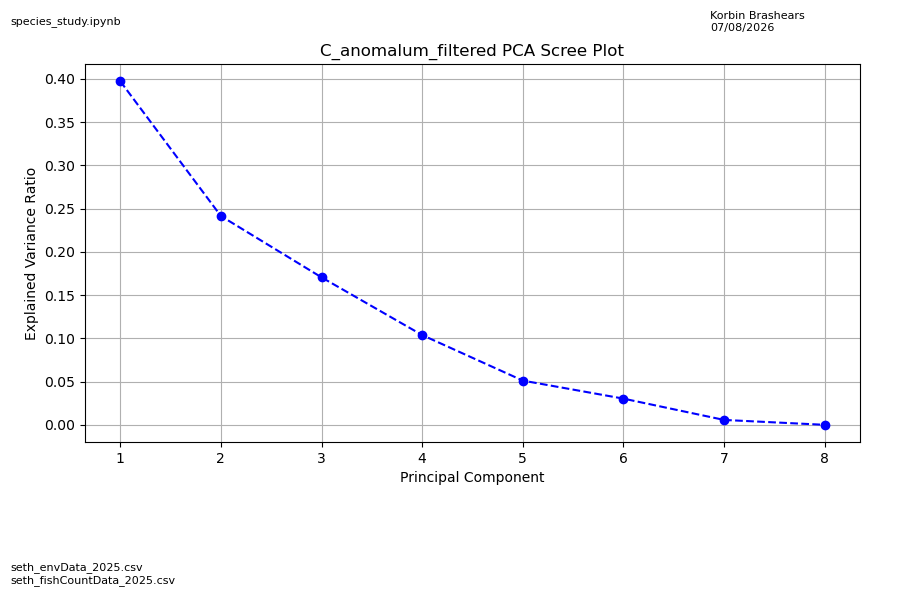


PCA Loadings for C_anomalum_filtered
                      PC1     PC2     PC3     PC4     PC5     PC6     PC7  \
DO                -0.1070  0.2674  0.0262 -0.4318  0.2807 -0.0441  0.1198   
pH                 0.2304  0.1089 -0.3351 -0.0756 -0.1378 -0.0546 -0.3524   
avg_WW             0.2987  0.1560  0.0805  0.0035  0.0188 -0.3098  0.1289   
avg_Depth          0.0130  0.2458 -0.4003 -0.1147 -0.0668 -0.2030  0.3363   
pf_Pool           -0.1441 -0.1910 -0.3778  0.1249  0.1302  0.2283 -0.0217   
pf_Run             0.0660  0.2943  0.3608  0.0040 -0.1072 -0.0138 -0.0715   
pf_Riffle          0.1064 -0.3336 -0.1523 -0.2324  0.0131 -0.3768  0.2030   
pb_Mud             0.1252 -0.3200 -0.1841 -0.2869  0.0080  0.0640 -0.1006   
pb_Sand            0.1340  0.3155 -0.0626  0.2306  0.3379  0.2512 -0.2522   
pb_SmGravel        0.2000  0.0988 -0.3226  0.2870  0.0680 -0.1401  0.1185   
pb_LgGravel        0.0594  0.2654 -0.0856  0.4811 -0.1442 -0.1528  0.0266   
pb_Cobble         -0.1405  0.3433 -0.0

In [168]:
pca_loadings = pca_decay_plotter(metrics_filtered, title_prefix="C_anomalum_filtered")

In [169]:
def plot_top_pca_loadings(loadings, top_pcs=3, top_vars=5):
    """
    Visualize the top N loadings for the top N principal components.
    Produces one horizontal bar chart per PC.
    """

    for pc in range(top_pcs):
        pc_name = f"PC{pc+1}"

        # Get absolute loadings and sort
        sorted_loadings = loadings[pc_name].abs().sort_values(ascending=False)

        # Select top variables
        top_loads = sorted_loadings.head(top_vars)
        top_vars_names = top_loads.index
        top_vals = loadings.loc[top_vars_names, pc_name]

        # Plot
        plt.figure(figsize=(10, 6))
        
        plt.subplot(2, 1, 1)
        
        plt.barh(top_vars_names, top_vals, color="steelblue")
        plt.xlabel("Loading Value")
        plt.title(f"Top {top_vars} Loadings for {pc_name}")
        plt.gca().invert_yaxis()  # highest at top
        plt.grid(axis="x", linestyle="--", alpha=0.5)
        
        plt.subplot(2, 1, 2)

        plt.plot(
            sorted_loadings.index,
            sorted_loadings.values,
            marker='o',
            color="steelblue"
        )

        plt.xticks(sorted_loadings.index, rotation=45, ha='right')
        plt.ylabel("Loading Value")
        plt.title("Sorted Loadings Decay Plot")

        plt.tight_layout()
        
        lpe(
            author_names="Korbin Brashears",
            data_filenames=[filenames['s_ed'], filenames['s_fcd']],
            fig_filename=f"../figures/pca_top_loadings_{pc_name}.png",
            save=False
        )

        plt.show()


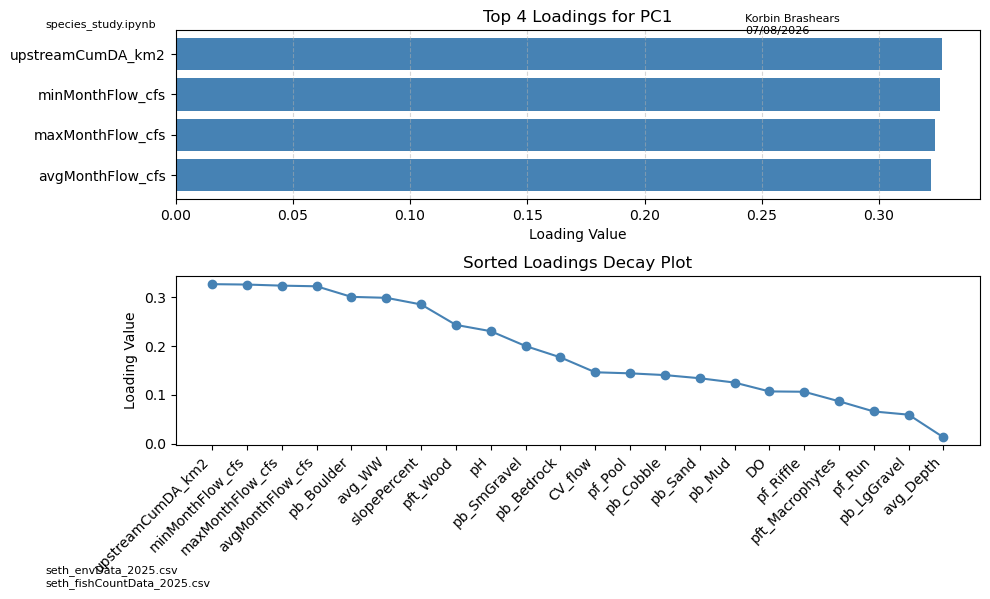

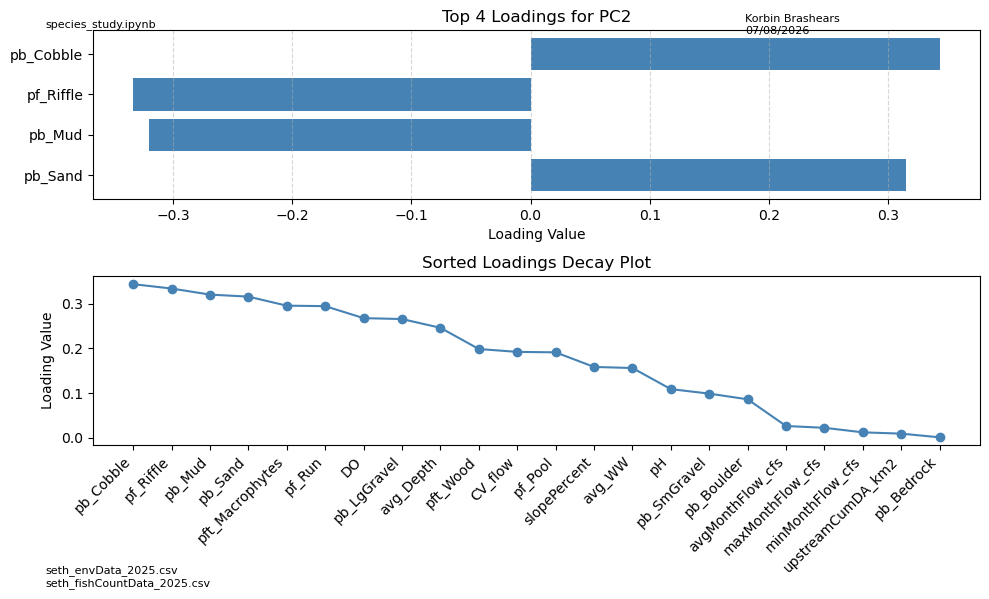

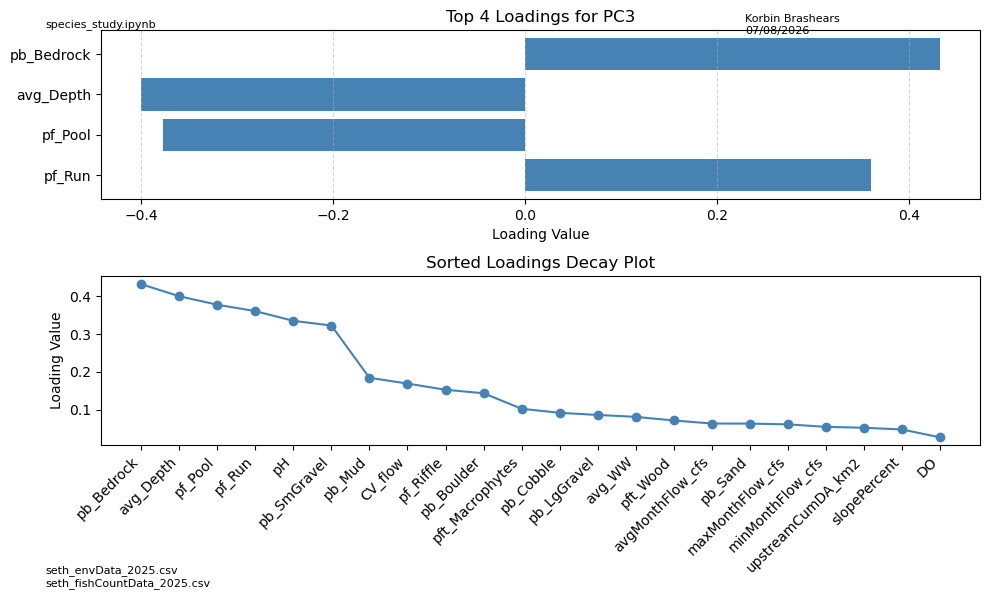

In [170]:
plot_top_pca_loadings(pca_loadings, top_pcs=3, top_vars=4)

**Current interpretation:**
* PC1, PC2, and PC3 explain a relevant level of variance in the sites containing N >= 10 of our *C. anomalum*.
* This suggests that the loadings of these principal components may point to key drivers of the population.

**Principal Component Highest Loadings**

* **PC1:**  
  * Loadings seem to point to the min, max, average, and upstream flow metrics primarily contributing to this component.  
  * PC1 has a shallow drop‑off, but its top four loadings show that the flow metrics contribute the most to the variance.

* **PC2:**  
  * Loadings seem to point to the Cobble, Riffle, Mud, and Sand metrics primarily contributing to this component.  
  * At first it seems odd that mud, cobble, and sand load highly alongside riffle, but using the correlation heat matrix from `kbrashears_fishData_report_02042026.ipynb`, these metrics actually show relatively high correlation (around 0.3).  
  * This likely reflects that the bottom composition of the river has a strong relationship with flow and channel shape, similar to riffle.

* **PC3:**  
  * Loadings seem to point to the Bedrock, Depth, Pool, and Run metrics primarily contributing to this component.  
  * This again indicates that pooling/flow combined with bottom composition explains much of the variance in our sites containing *C. anomalum*.

> **Conclusion**  
> These results support that the most influential variables in our clustering of these sites are the flow characteristics and the composition of the streambed. This suggests that riverbed composition may be the most telling factor for *C. anomalum*, as flow often correlates with whether the substrate contains the small gravel needed for spawning.  
>  
> In areas with high sediment but strong flow, larger gravel can settle while mud and sand wash away; in low‑flow areas, mud and sand accumulate, potentially smothering eggs or preventing spawning altogether.  
>  
> The primary exception is bedrock bottoms: when the substrate is solid rock, flow does not separate gravel or sediment. In these cases, the water may be fast or slow, but flow has little effect on substrate composition because the bottom cannot shift.


<h3>Niche Variance Interpretation</h3>

> To understand which environmental metrics define the realized niche of *Campostoma anomalum*, we computed the variance of each metric across only the sites where the species occurs in ecologically meaningful numbers (N > 10).  
>  
> Metrics with **low variance** are highly consistent across all anomalum sites, indicating **key habitat requirements**. These variables do not vary much within occupied habitat and therefore represent stable environmental conditions preferred by the species.  
>  
> Metrics with **high variance** fluctuate widely even where anomalum is present, suggesting that the species **tolerates** variation in these conditions. These variables are less likely to be primary drivers of habitat selection.  
>  
> This variance‑based approach complements PCA by identifying which environmental factors are stable within the species’ niche (important) versus those that vary substantially (tolerated).


> Comparing the ratio of the Std of each environmental metric with the Std for only the C. Anomalum sites.

In [171]:
base_std = np.std(metrics_all, axis=0)
filtered_std = np.std(metrics_filtered, axis=0)

std_m = pd.concat([base_std, filtered_std], axis=1)

std_m['std_ratio'] = std_m[1]/std_m[0]

print(std_m)

                            0           1  std_ratio
DO                   2.895852    3.901282   1.347197
pH                   0.583217    0.344708   0.591045
avg_WW               4.101073    3.281298   0.800107
avg_Depth           12.575821    9.054595   0.720000
pf_Pool             22.446256   14.433755   0.643036
pf_Run              22.086560   18.517072   0.838386
pf_Riffle           15.099368    8.068717   0.534374
pb_Mud              34.850670   20.885940   0.599298
pb_Sand             11.151883    5.162122   0.462892
pb_SmGravel         12.847268    9.564575   0.744483
pb_LgGravel         10.420673    9.204678   0.883309
pb_Cobble            8.150498    5.897550   0.723581
pb_Boulder          10.563794    3.889549   0.368196
pb_Bedrock          17.237409   21.116744   1.225053
pft_Macrophytes     30.959930   33.071891   1.068216
pft_Wood            32.026684   28.182811   0.879979
upstreamCumDA_km2  224.491729  123.482126   0.550052
slopePercent         0.376918    0.311649   0.

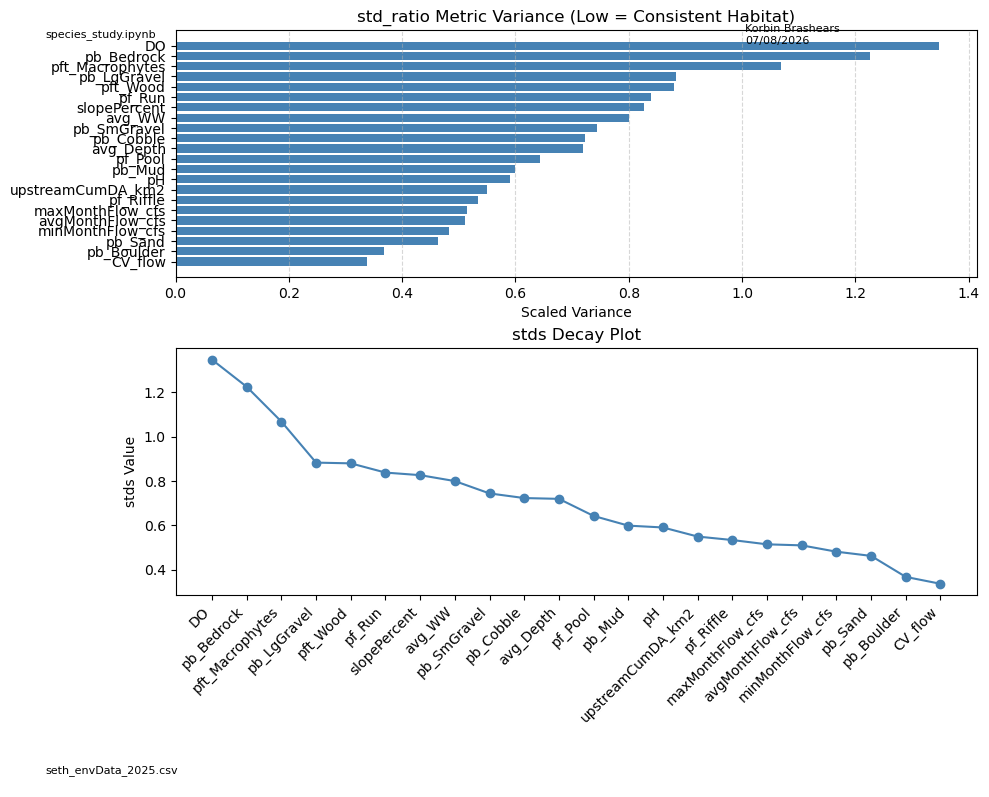

In [172]:
# 3. Compute variance within anomalum sites
stds = std_m['std_ratio'].sort_values(ascending=False)
#stds = pd.Series(variances, index=std_m.columns).sort_values()

# 4. Plot
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.barh(stds.index, stds.values, color="steelblue")
plt.xlabel("Scaled Variance")
plt.title(f"std_ratio Metric Variance (Low = Consistent Habitat)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().invert_yaxis()

plt.subplot(2, 1, 2)

plt.plot(
    stds.index,
    stds.values,
    marker='o',
    color="steelblue"
)

plt.xticks(stds.index, rotation=45, ha='right')
plt.ylabel("stds Value")
plt.title("stds Decay Plot")

plt.tight_layout()

lpe(
    author_names="Korbin Brashears",
    data_filenames=filenames['s_ed'],
    fig_filename=f"../figures/niche_variance_std_ratio.png",
    save=False
)


**Std Results Interpretation**

> It seems like these results generally line up with our previous conclusion that flow, channel shape, and bed composition matter the most, as they vary the least within these sites. We see a very steep drop‑off in standard deviation after DO, Bedrock, and Macrophytes. This is somewhat surprising because we expected Macrophytes and Bedrock to be larger contributors.
>
> It is important to note that this does *not* mean these variables are unimportant, only that they are likely not the primary drivers of variation within the filtered sites.
>
> We can also see that, as expected, CV_flow along with min, average, and upstream flow metrics are largely consistent across these sites. Additionally, pf_riffle, pb_boulder, and Sand appear consistent as well. The remaining variables—average depth, small gravel, pf_run, and others, fall into a middle range of variability but are still much more consistent than DO, Bedrock, and Macrophytes.

<br/>

> I would like to next plot a bar chart comparing the average of each metric across *all* sites versus the averages across only our filtered sites to better visualize these differences.


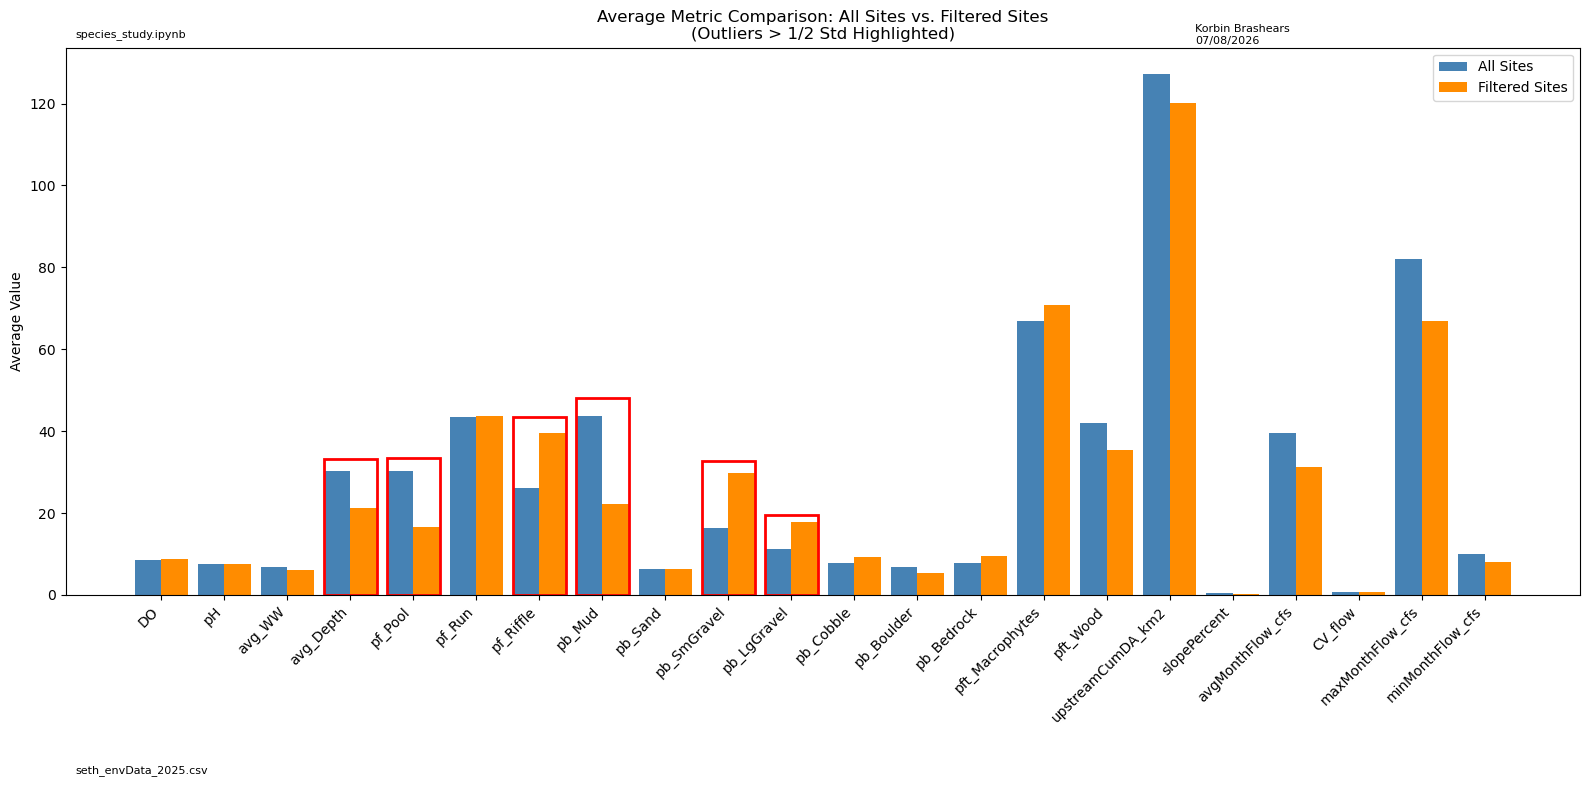

In [173]:
# Compute means
mean_all = metrics_all.mean()
mean_filtered = metrics_filtered.mean()

# Compute std across ALL sites (used as threshold)
std_all = metrics_all.std()

# Difference between filtered and all
diff = (mean_filtered - mean_all).abs()

# Identify metrics where difference > 1/2 std
outlier_metrics = diff[diff > std_all*0.5].index.tolist()

# Combine into a DataFrame for plotting
mean_df = pd.DataFrame({
    "All Sites": mean_all,
    "Filtered Sites": mean_filtered,
    "Diff": diff,
    "Std_All": std_all
}) # X positions
x = np.arange(len(mean_df))
width = 0.42

plt.figure(figsize=(16, 8))

# Bars
bars_all = plt.bar(x - width/2, mean_df["All Sites"], 
                   width=width, label="All Sites", color="steelblue")

bars_filtered = plt.bar(x + width/2, mean_df["Filtered Sites"], 
                        width=width, label="Filtered Sites", color="darkorange")

# Highlight metrics where difference > 1 std
for i, metric in enumerate(mean_df.index):
    if metric in outlier_metrics:
        # Draw a red rectangle around both bars for this metric
        rect = patches.Rectangle(
            (i - width, 0),      # x-position (slightly left of both bars)
            width*2,             # width covering both bars
            max(mean_df.loc[metric, ["All Sites", "Filtered Sites"]]) * 1.1,  # height
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        plt.gca().add_patch(rect)

# Labels
plt.xticks(x, mean_df.index, rotation=45, ha='right')
plt.ylabel("Average Value")
plt.title("Average Metric Comparison: All Sites vs. Filtered Sites\n(Outliers > 1/2 Std Highlighted)")
plt.legend()

plt.tight_layout()

lpe(
    author_names="Korbin Brashears",
    data_filenames=filenames['s_ed'],
    fig_filename="../figures/niche_variance_std_ratio.png",
    save=False
)

plt.show()

<h3>Interpretation of Average Differences Between All Sites and Filtered Sites</h3>

The comparison between the average environmental metrics across *all* sites and those from only the filtered sites containing **N ≥ 10 C. anomalum** reveals a consistent and ecologically meaningful pattern. Several substrate and channel‑shape variables shift in ways that align with known habitat preferences of *Campostoma anomalum*, even though many of these differences were not flagged by the 1/2‑standard‑deviation threshold used in the variance analysis.

<h3>Substrate and Channel Characteristics</h3>

Across the filtered sites, we observe:

- **Lower average depth**, indicating a preference for shallow water.
- **Substantially lower pool proportion**, nearly half of the full‑dataset average.
- **Higher riffle proportion**, roughly one‑quarter greater than all sites.
- **Lower mud proportion**, approximately half of the full‑dataset average.
- **Higher small‑gravel proportion**, nearly double, which is the strongest substrate signal.
- **Moderately higher large‑gravel proportion**, consistent with stable riffle substrates.

Together, these shifts outline a clear habitat signature: shallow, fast‑moving riffle environments with stable gravel substrates and reduced fine sediment. These conditions are well documented as essential for feeding and spawning in *C. anomalum*.

<h3>Flow Characteristics</h3>

Flow‑related metrics show a more subtle pattern:

- **Upstream flow, average monthly flow, max flow, and min flow** are all slightly lower in filtered sites.
- **CV_flow is identical** between groups.
- **General flow appears lower overall** in occupied sites.

Although initially surprising, this pattern is consistent with riffle ecology. *C. anomalum* does not require high discharge; instead, it relies on **stable riffle conditions** where gravel remains in place and fine sediment does not accumulate. Excessively high flow can scour gravel, while very low flow promotes mud and sand deposition. The filtered sites appear to represent moderate‑flow environments that maintain substrate stability rather than extremes of discharge.

<h3>Vegetation and Wood</h3>

- **Macrophytes are slightly higher** in filtered sites, which may reflect stable substrate conditions in moderate‑flow reaches.
- **Wood proportion is slightly lower**, consistent with riffles where woody debris is less likely to accumulate.

These differences are small but fit the broader riffle‑versus‑pool contrast observed in the substrate metrics.

<h3>Why PCA Loadings and Niche Variance Did Not Flag These Metrics</h3>

Several of the ecologically meaningful differences-such as lower depth, higher riffle, reduced mud, and increased small gravel-were not flagged by the 1‑standard‑deviation threshold. This is because PCA and niche variance highlight variables that **explain variance**, not variables that **explain ecological preference**. Metrics like CV_flow and upstream flow were flagged only because they are extremely consistent across filtered sites, not because they are biologically influential. The mean‑difference comparison provides a complementary perspective, revealing ecological signals that PCA cannot capture.

<h3>Emerging Habitat Blueprint for <i>C. anomalum</i> Sites (N ≥ 10)</h3>

The filtered sites share a coherent environmental profile:

- Lower average depth  
- Lower pooling  
- Higher riffle proportion  
- Lower mud  
- Higher small gravel  
- Slightly higher large gravel  
- Moderate, stable flow conditions  

This combination strongly supports the conclusion that *C. anomalum* occupies shallow, riffle‑dominated habitats with stable gravel substrates and minimal fine sediment. The mean‑difference analysis reinforces and clarifies the ecological interpretation suggested by the PCA and variance results.

<hr/>

<h2>Testing Our Results by Scoring Each Site’s Feature–Population Combinations</h2>

> To evaluate whether our final habitat hypothesis matches the actual site‑level data, we will create a function that scores each site according to our expected “blueprint” features. Each feature will be scaled from **0 to 1**, where **0** corresponds to the minimum value of that feature across *all* sites and **1** corresponds to the maximum value across all sites. These min–max values will come from `metrics_all`, not from `metrics_filtered`, so that the scoring reflects the full environmental range of the dataset.
>
> For each site, the function will compute a 0–1 score for every blueprint feature (e.g., depth, riffle, mud, small gravel, large gravel, flow metrics). These standardized values will be stored as a row in a new DataFrame. The final output will contain all 46 sites, each with:
>
> * the site number  
> * the 0–1 scaled feature scores  
> * the *C. anomalum* count for that site  
>
> This will allow us to visually inspect whether the feature combinations at each site align with our ecological expectations. If the general patterns appear correct—meaning high scores for riffle and small gravel correspond to higher *C. anomalum* counts, while high mud or deep pooling correspond to lower counts—then we can proceed to the next step.

<br/>

> Once the scoring system is validated, we will extend it by creating a **weighted “population score” function**. This function will multiply each standardized feature by a weight representing its hypothesized importance (e.g., small gravel weighted more heavily than macrophytes). The resulting weighted score will estimate the likelihood that a site supports high *C. anomalum* abundance. This will serve as a preliminary habitat suitability index that can be refined or validated with additional modeling.


In [174]:
# Precompute min and max for all features across ALL sites
feature_min = metrics_all.min()
feature_max = metrics_all.max()

def scale_site_features(site_row):
    """
    Takes a row from metrics_all or metrics_filtered and returns
    a dict of 0–1 scaled feature values using global min/max.
    """
    scaled = (site_row - feature_min) / (feature_max - feature_min)
    return scaled.round(2)   # round to 2 decimals as requested

In [ ]:
# Extract the site numbers
site_numbers = s_ed["SiteN"]

# Compute scaled features for each site
scaled_rows = []
for idx, row in metrics_all.iterrows():
    scaled = scale_site_features(row)
    scaled["SiteN"] = site_numbers.loc[idx]
    scaled["C_anomalum_count"] = s_fcd['Campostoma_anomalum'].loc[idx]
    scaled_rows.append(scaled)

# Final DataFrame
scaled_df = pd.DataFrame(scaled_rows)

# Reorder columns: SiteN, C_anomalum_count, then features
cols = ["SiteN", "C_anomalum_count"] + [c for c in scaled_df.columns if c not in ["SiteN", "C_anomalum_count"]]
scaled_df = scaled_df[cols]

scaled_df.head()


,SiteN,C_anomalum_count,DO,pH,avg_WW,avg_Depth,pf_Pool,pf_Run,pf_Riffle,pb_Mud,...,pb_Boulder,pb_Bedrock,pft_Macrophytes,pft_Wood,upstreamCumDA_km2,slopePercent,avgMonthFlow_cfs,CV_flow,maxMonthFlow_cfs,minMonthFlow_cfs
0,1.0,1.0,0.45,0.26,0.17,0.34,0.00,1.00,0.33,0.48,...,0.20,0.18,0.83,0.17,0.03,0.19,0.03,0.54,0.03,0.03
1,2.0,0.0,0.00,0.33,0.02,0.40,0.60,0.24,0.40,0.77,...,0.00,0.00,0.60,0.40,0.01,0.19,0.01,0.57,0.01,0.01
2,3.0,0.0,0.22,0.43,0.45,0.75,0.67,0.40,0.00,0.58,...,0.00,0.00,0.83,1.00,0.07,0.02,0.07,0.42,0.07,0.08
3,4.0,36.0,0.24,0.51,0.41,0.25,0.00,0.80,0.67,0.20,...,0.00,0.00,0.50,0.83,0.33,0.05,0.30,0.48,0.31,0.29
4,5.0,0.0,0.18,0.39,1.00,0.63,1.00,0.00,0.00,0.95,...,0.05,0.00,1.00,1.00,1.00,0.00,1.00,0.48,1.00,1.00


In [ ]:
# Example weights based on your blueprint interpretation
weights = {
    "avg_Depth": -1.0,          # shallower sites preferred
    "pf_Pool": -1.5,            # less pooling strongly preferred
    "pf_Riffle": 2.0,           # riffle habitat highly preferred
    "pb_Mud": -2.0,             # mud strongly avoided
    "pb_SmGravel": 2.5,         # small gravel extremely important (spawning substrate)
    "pb_LgGravel": 1.0,         # large gravel moderately helpful
    "avgMonthFlow_cfs": 0.5,    # moderate flow beneficial
    "CV_flow": 0.0,             # flow consistency not predictive
    "pf_Run": 0.5,              # run habitat moderately helpful
    "pb_Boulder": 0.5,          # stable substrate helpful
    "pb_Sand": -1.0,            # sand mildly avoided
    "pft_Macrophytes": 0.2,     # slight positive association
    "pft_Wood": -0.2,           # wood slightly avoided (accumulates in pools)
    "maxMonthFlow_cfs": -0.3,   # extreme high flows harmful (scour)
    "minMonthFlow_cfs": -0.3,   # extreme low flows harmful (sediment deposition)
    "upstreamCumDA_km2": 0.1,   # slight positive drainage area effect
    "slopePercent": 0.1         # slight positive slope effect (riffle formation)
}

def compute_population_score(row, weights):
    score = 0
    for feature, weight in weights.items():
        if feature in row.index:
            score += row[feature] * weight
    return score   # keep full precision

# Apply raw score
scaled_df["population_score_raw"] = scaled_df.apply(
    lambda r: compute_population_score(r, weights), axis=1
)

# Normalize raw score to 0–1 probability-like score
min_score = scaled_df["population_score_raw"].min()
max_score = scaled_df["population_score_raw"].max()

scaled_df["population_score"] = (
    (scaled_df["population_score_raw"] - min_score) /
    (max_score - min_score)
).round(3)

scaled_df.head()


,SiteN,C_anomalum_count,DO,pH,avg_WW,avg_Depth,pf_Pool,pf_Run,pf_Riffle,pb_Mud,...,pft_Macrophytes,pft_Wood,upstreamCumDA_km2,slopePercent,avgMonthFlow_cfs,CV_flow,maxMonthFlow_cfs,minMonthFlow_cfs,population_score_raw,population_score
0,1.0,1.0,0.45,0.26,0.17,0.34,0.00,1.00,0.33,0.48,...,0.83,0.17,0.03,0.19,0.03,0.54,0.03,0.03,1.006,0.581
1,2.0,0.0,0.00,0.33,0.02,0.40,0.60,0.24,0.40,0.77,...,0.60,0.40,0.01,0.19,0.01,0.57,0.01,0.01,-1.961,0.230
2,3.0,0.0,0.22,0.43,0.45,0.75,0.67,0.40,0.00,0.58,...,0.83,1.00,0.07,0.02,0.07,0.42,0.07,0.08,-3.510,0.047
3,4.0,36.0,0.24,0.51,0.41,0.25,0.00,0.80,0.67,0.20,...,0.50,0.83,0.33,0.05,0.30,0.48,0.31,0.29,3.562,0.884
4,5.0,0.0,0.18,0.39,1.00,0.63,1.00,0.00,0.00,0.95,...,1.00,1.00,1.00,0.00,1.00,0.48,1.00,1.00,-3.905,0.000


In [ ]:
scaled_df.to_csv('../data/species_study/scaled_1to0_rating.csv')

In [ ]:
print(scaled_df[["population_score", "C_anomalum_count"]].corr())

                  population_score  C_anomalum_count
population_score          1.000000          0.441385
C_anomalum_count          0.441385          1.000000


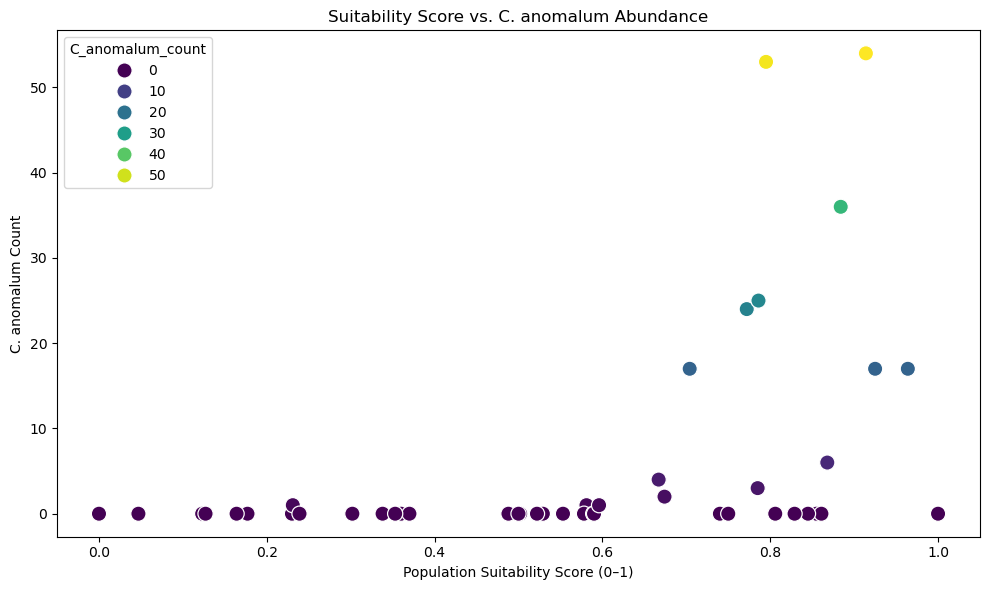

In [ ]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=scaled_df,
    x="population_score",
    y="C_anomalum_count",
    hue="C_anomalum_count",
    palette="viridis",
    s=120
)

plt.title("Suitability Score vs. C. anomalum Abundance")
plt.xlabel("Population Suitability Score (0–1)")
plt.ylabel("C. anomalum Count")
plt.tight_layout()
plt.show()


> Using our weighted scores to create a binary classify for N>=10 C. Anomalum.

In [ ]:
# Creating a binary column for C. anomalum presence based on a threshold of 10 individuals

scaled_df["C_anomalum_binary"] = (scaled_df["C_anomalum_count"] >= 10).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = scaled_df[["population_score"]]   # single predictor
y = scaled_df["C_anomalum_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [182]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.75
[[9 0]
 [3 0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         9
           1       0.00      0.00      0.00         3

    accuracy                           0.75        12
   macro avg       0.38      0.50      0.43        12
weighted avg       0.56      0.75      0.64        12



c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Korbin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


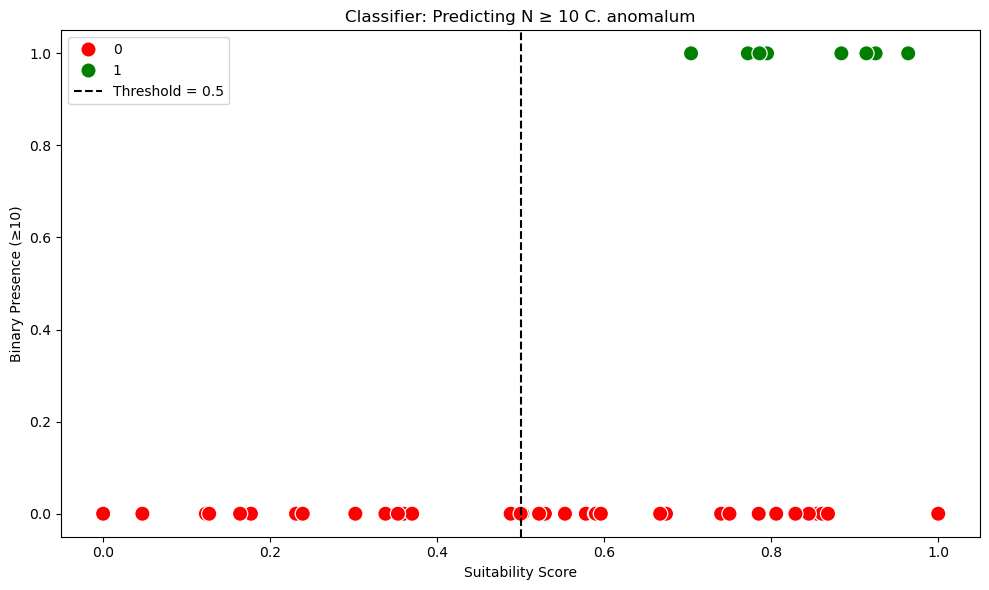

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=scaled_df,
    x="population_score",
    y="C_anomalum_binary",
    hue="C_anomalum_binary",
    palette=["red","green"],
    s=120
)

plt.axvline(0.5, color="black", linestyle="--", label="Threshold = 0.5")
plt.title("Classifier: Predicting N ≥ 10 C. anomalum")
plt.xlabel("Suitability Score")
plt.ylabel("Binary Presence (≥10)")
plt.legend()
plt.tight_layout()
plt.show()


>From these plots, we can clearly see that our current suitability score can do a good job of showing whether or not a site is not inhabitable by Campsotma Anomalum; however, it also shows that, while a site may be habitable, that does not necessarily mean that it will be inhabited. 

> From this analysis I would like to propose to myself that we should include a separate metric perhaps from trying to predict whether there will be fish but rather could there be. Essentially I would like to try to identify if a given site is not inhabitable, and what make it so.
<hr>



> Creating a weight tuning function to find the highest correlation between Suitability Score and population.

In [ ]:

def evolve_weights(
    scaled_df,
    FEATURE_NAMES,
    pop_size=50,
    generations=200,
    mutation_rate=0.15,
    weight_range=(-3, 3),
    seed=42
):
    np.random.seed(seed)

    # Extract abundance vector
    y = scaled_df["C_anomalum_count"].values

    # --- Initialize population of random weight sets ---
    population = [
        {feat: np.random.uniform(*weight_range) for feat in FEATURE_NAMES}
        for _ in range(pop_size)
    ]

    def fitness(weights):
        raw = scaled_df.apply(
            lambda r: sum(r[f] * weights[f] for f in FEATURE_NAMES),
            axis=1
        )
        norm = (raw - raw.min()) / (raw.max() - raw.min())
        return np.corrcoef(norm, y)[0, 1]

    best_corr = -999
    c_anomalum_weights = None

    for gen in range(generations):

        # --- Evaluate fitness of each weight set ---
        scored = [(fitness(w), w) for w in population]
        scored.sort(key=lambda x: x[0], reverse=True)

        # Track best
        if scored[0][0] > best_corr:
            best_corr = scored[0][0]
            c_anomalum_weights = scored[0][1]

        # --- Select top 20% as parents ---
        parents = [w for _, w in scored[:pop_size // 5]]

        # --- Create new population via crossover ---
        new_population = []

        while len(new_population) < pop_size:
            p1, p2 = np.random.choice(parents, 2, replace=True)
            child = {}

            for feat in FEATURE_NAMES:
                # crossover: mix parent weights
                if np.random.rand() < 0.5:
                    child[feat] = p1[feat]
                else:
                    child[feat] = p2[feat]

                # mutation
                if np.random.rand() < mutation_rate:
                    child[feat] += np.random.uniform(-1, 1)

            new_population.append(child)

        population = new_population

    return best_corr, c_anomalum_weights


In [ ]:
# best_corr, c_anomalum_weights = evolve_weights(
#     scaled_df, 
#     FEATURE_NAMES,
#     generations=400
#     )

# print("Best Correlation:", best_corr)
# print("Best Weights:", c_anomalum_weights)

> Adding meaningful weight bounds for our alg to follow.

In [186]:
weight_bounds = {
    "avg_Depth": (-3, -0.1),        # must be negative
    "pf_Pool": (-4, -0.5),          # must be strongly negative
    "pf_Riffle": (0.5, 4),          # must be positive
    "pb_Mud": (-4, -0.5),           # must be strongly negative
    "pb_SmGravel": (1, 5),          # must be strongly positive
    "pb_LgGravel": (0, 2),          # mild positive
    "avgMonthFlow_cfs": (-1, 1),    # moderate effect
    "CV_flow": (-1, 1),             # weak effect
    "pf_Run": (0, 2),               # mild positive
    "pb_Boulder": (0, 2),           # mild positive
    "pb_Sand": (-2, 0),             # negative
    "pft_Macrophytes": (-1, 1),     # weak effect
    "pft_Wood": (-1, 1),            # weak effect
    "maxMonthFlow_cfs": (-2, 0),    # negative
    "minMonthFlow_cfs": (-1, 1),    # weak effect
    "upstreamCumDA_km2": (-1, 1),   # weak effect
    "slopePercent": (0, 2)          # positive
}

In [ ]:
def evolve_weights_constrained(
    scaled_df,
    FEATURE_NAMES,
    weight_bounds,
    pop_size=200,
    generations=200,
    mutation_rate=0.15,
    seed=42
):
    np.random.seed(seed)
    y = scaled_df["C_anomalum_count"].values

    # --- Initialize population ---
    def random_weights():
        return {
            feat: np.random.uniform(*weight_bounds[feat])
            for feat in FEATURE_NAMES
        }

    population = [random_weights() for _ in range(pop_size)]

    def fitness(weights):
        # Compute raw score
        raw = scaled_df.apply(
            lambda r: sum(r[f] * weights[f] for f in FEATURE_NAMES),
            axis=1
        )
        norm = (raw - raw.min()) / (raw.max() - raw.min())
        corr = np.corrcoef(norm, y)[0, 1]

        # Penalty for violating ecological expectations
        penalty = 0

        # Small gravel MUST be high
        if weights["pb_SmGravel"] < 1.5:
            penalty -= 0.2

        # Riffle MUST be positive
        if weights["pf_Riffle"] < 0.5:
            penalty -= 0.2

        # Mud MUST be negative
        if weights["pb_Mud"] > -0.5:
            penalty -= 0.2

        # Pool MUST be strongly negative
        if weights["pf_Pool"] > -0.5:
            penalty -= 0.2

        # Prevent extreme magnitudes
        for feat in FEATURE_NAMES:
            low, high = weight_bounds[feat]
            if not (low <= weights[feat] <= high):
                penalty -= 0.5

        return corr + penalty

    best_corr = -999
    c_anomalum_weights = None

    for gen in range(generations):

        scored = [(fitness(w), w) for w in population]
        scored.sort(key=lambda x: x[0], reverse=True)

        if scored[0][0] > best_corr:
            best_corr = scored[0][0]
            c_anomalum_weights = scored[0][1]

        parents = [w for _, w in scored[:pop_size // 5]]

        new_population = []
        while len(new_population) < pop_size:
            p1, p2 = np.random.choice(parents, 2, replace=True)
            child = {}

            for feat in FEATURE_NAMES:
                child[feat] = p1[feat] if np.random.rand() < 0.5 else p2[feat]

                # mutation
                if np.random.rand() < mutation_rate:
                    low, high = weight_bounds[feat]
                    child[feat] = np.random.uniform(low, high)

            new_population.append(child)

        population = new_population

    return best_corr, c_anomalum_weights


In [ ]:
# best_corr, c_anomalum_weights = evolve_weights_constrained(
#     scaled_df,
#     FEATURE_NAMES,
#     weight_bounds
# )

# print("Best Corr:", best_corr)
# print("Best Weights:", c_anomalum_weights)

In [ ]:
# y = scaled_df['C_anomalum_count'].values

# # vectorized raw score
# w = np.array([c_anomalum_weights[f] for f in FEATURE_NAMES])
# X = scaled_df[FEATURE_NAMES].values
# raw = np.sum(X * w, axis=1)

# # normalize

# corr = np.corrcoef(raw, y)[0, 1]

# print("Final correlation:", corr)

> Creating a better algorithm.
> 
> This one will utilize a path-finding local maxima with random stepping to try to find the best correlation point in the 17dim space.

<hr/>

In [ ]:
from joblib import Parallel, delayed

# ---------- GLOBALS ----------
GLOBAL_DF = None
GLOBAL_FEATURES = None
GLOBAL_BOUNDS = None

# ---------- RAW CORRELATION (no penalties) ----------
def raw_corr(weights, binary=False):
    df = GLOBAL_DF
    FEATURE_NAMES = GLOBAL_FEATURES

    if binary:
        y = df['C_anomalum_binary'].values
    else:
        y = df['C_anomalum_count'].values

    w = np.array([weights[f] for f in FEATURE_NAMES])
    X = df[FEATURE_NAMES].values

    raw = np.sum(X * w, axis=1)
    rmin, rmax = raw.min(), raw.max()
    if rmax == rmin:
        return None

    norm = (raw - rmin) / (rmax - rmin)
    return np.corrcoef(norm, y)[0, 1]

# ---------- PENALTIES (applied AFTER climbing) ----------
def apply_penalties(weights):
    penalty = 0
    if weights["pb_SmGravel"] < 1.5:
        penalty -= 0.2
    if weights["pf_Riffle"] < 0.5:
        penalty -= 0.2
    if weights["pb_Mud"] > -0.5:
        penalty -= 0.2
    if weights["pf_Pool"] > -0.5:
        penalty -= 0.2

    for feat in GLOBAL_FEATURES:
        low, high = GLOBAL_BOUNDS[feat]
        if not (low <= weights[feat] <= high):
            penalty -= 0.5

    return penalty

# ---------- RANDOM START ----------
def random_weights():
    return {
        feat: np.random.uniform(*GLOBAL_BOUNDS[feat])
        for feat in GLOBAL_FEATURES
    }

# ---------- OPTIMIZED HILL-CLIMB WORKER ----------
def hill_climb_worker(seed):
    np.random.seed(seed)

    weights = random_weights()
    best_corr = raw_corr(weights, binary=GLOBAL_BINARY)

    if best_corr is None:
        return (None, None)

    # adaptive step schedule
    step_sizes = [1.0, 0.5, 0.25, 0.1, 0.05, 0.01, 0.005, 0.001]

    for step in step_sizes:
        improved = True

        while improved:
            improved = False

            # diagonal stepping: adjust multiple features at once
            for feat in GLOBAL_FEATURES:
                low, high = GLOBAL_BOUNDS[feat]

                # +step
                w_plus = weights.copy()
                w_plus[feat] = min(w_plus[feat] + step, high)
                c_plus = raw_corr(w_plus)

                # -step
                w_minus = weights.copy()
                w_minus[feat] = max(w_minus[feat] - step, low)
                c_minus = raw_corr(w_minus)

                # choose best direction
                if c_plus is not None and c_plus > best_corr:
                    weights = w_plus
                    best_corr = c_plus
                    improved = True
                    continue

                if c_minus is not None and c_minus > best_corr:
                    weights = w_minus
                    best_corr = c_minus
                    improved = True
                    continue

    # apply penalties AFTER climbing
    final_score = best_corr + apply_penalties(weights)
    return (weights, final_score)

# ---------- PARALLEL DRIVER ----------
def parallel_hill_climb(
    scaled_df,
    FEATURE_NAMES,
    weight_bounds,
    n_parallel=8,
    n_restarts_per_worker=2,
    binary=False
):
    global GLOBAL_DF, GLOBAL_FEATURES, GLOBAL_BOUNDS, GLOBAL_BINARY
    GLOBAL_DF = scaled_df
    GLOBAL_FEATURES = FEATURE_NAMES
    GLOBAL_BOUNDS = weight_bounds
    GLOBAL_BINARY = binary

    seeds = list(range(n_parallel * n_restarts_per_worker))

    results = Parallel(n_jobs=n_parallel, backend="loky")(
        delayed(hill_climb_worker)(seed) for seed in seeds
    )

    c_anomalum_weights = None
    best_score = -999

    for w, s in results:
        if s is None:
            continue
        if s > best_score:
            best_score = s
            c_anomalum_weights = w

    return best_score, c_anomalum_weights


> Trying with raw count.

In [ ]:
# best_corr, c_anomalum_weights = parallel_hill_climb(
#     scaled_df,
#     FEATURE_NAMES,
#     weight_bounds,
#     n_parallel=8,
#     n_restarts_per_worker=20,
# )
# print("Best Corr (with penalties):", best_corr)
# print("Best Weights:", c_anomalum_weights)

In [ ]:
# y = scaled_df['C_anomalum_count'].values

# # vectorized raw score
# w = np.array([c_anomalum_weights[f] for f in FEATURE_NAMES])
# X = scaled_df[FEATURE_NAMES].values
# raw = np.sum(X * w, axis=1)

# # normalize

# corr = np.corrcoef(raw, y)[0, 1]

# print("Final correlation:", corr)

In [ ]:
# y = scaled_df['C_anomalum_count'].values

# # vectorized raw score
# w = np.array([c_anomalum_weights[f] for f in FEATURE_NAMES])
# X = scaled_df[FEATURE_NAMES].values
# raw = np.sum(X * w, axis=1)

# # normalize

# corr = np.corrcoef(raw, y)[0, 1]

# print("Final correlation:", corr)

In [ ]:
# y = scaled_df['C_anomalum_binary'].values

# # vectorized raw score
# w = np.array([c_anomalum_weights[f] for f in FEATURE_NAMES])
# X = scaled_df[FEATURE_NAMES].values
# raw = np.sum(X * w, axis=1)

# # normalize

# corr = np.corrcoef(raw, y)[0, 1]

# print("Final correlation:", corr)

> Trying with binary presence.

In [ ]:
# best_corr, c_anomalum_weights = parallel_hill_climb(
#     scaled_df,
#     FEATURE_NAMES,
#     weight_bounds,
#     n_parallel=8,
#     n_restarts_per_worker=20,    
#     binary=True
# )
# print("Best Corr (with penalties):", best_corr)
# print("Best Weights:", c_anomalum_weights)

In [ ]:
# y = scaled_df['C_anomalum_binary'].values

# # vectorized raw score
# w = np.array([c_anomalum_weights[f] for f in FEATURE_NAMES])
# X = scaled_df[FEATURE_NAMES].values
# raw = np.sum(X * w, axis=1)

# # normalize

# corr = np.corrcoef(raw, y)[0, 1]

# print("Final correlation:", corr)

<h3>Moving to a GA (genetic algorithm) for optimization of weights.</h3>

> To identify which environmental metrics best predict species presence or abundance, we used a genetic algorithm (GA) to evolve an optimal set of feature weights.  

> The GA evaluates thousands of candidate weight vectors and selects those that maximize the correlation between a weighted combination of environmental metrics and the target species response.  

> This approach is well suited for ecological data because it does not assume linearity, normality, or independence among predictors. The resulting weight vector provides a direct measure of each metric’s predictive contribution.

**How does GA work**

- **Initialize a population**  
  Create an initial set of candidate solutions (e.g., vectors of feature weights). Each individual represents one possible answer.

- **Define a fitness function**  
  Evaluate every individual by scoring how well it performs on the task - such as how strongly its weighted feature combination correlates with the target species metric.

- **Selection**  
  Choose the best‑performing individuals based on their fitness scores. These become the “parents” for the next generation.

- **Evolution (Crossover)**  
  Combine pairs of selected parents to produce new “children.” Each child inherits information from both parents, forming new candidate solutions.

- **Mutation**  
  Randomly perturb some of the children’s values. Mutation helps prevent the algorithm from getting stuck in local optima and encourages exploration of new solutions.

- **Repetition**  
  Repeat evaluation, selection, crossover, and mutation for many generations. Over time, the population evolves toward an optimal or near‑optimal solution.


In [197]:
# Moving to a GA algorithm for optimization of weights

# Importing DEAP library for genetic algorithm implementation
# The DEAP (Distributed Evolutionary Algorithms in Python) library is a framework for rapid prototyping and testing of ideas in evolutionary computation. 
# It provides tools for creating genetic algorithms, genetic programming, and other evolutionary algorithms.
# Unlike traditional optimization methods, DEAP allows for the evolution of solutions over generations, making it suitable for complex optimization problems where the search space is large or poorly understood.

# DEAP also utilizes Python's object-oriented programming features, allowing users to define custom fitness functions, individual representations, and genetic operators.

# DEAP makes us use the concept of "creator" to define the structure of individuals and their fitness. This allows for flexibility in defining what constitutes a solution and how its quality is measured.
# It also provides a "toolbox" for registering functions that will be used in the evolutionary process, such as selection, mutation, and crossover operations.

from deap import base, creator, tools, algorithms

# Define the fitness function and individual representation

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()




c:\Users\Korbin\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\Korbin\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


<hr/>

In [198]:
from deap import base, creator, tools, algorithms
from scipy.stats import spearmanr

def evaluate_weights(weights, X, y):
    weighted_sum = np.dot(X, weights)
    corr, _ = spearmanr(weighted_sum, y)
    return (abs(corr),)

def run_ga_weight_optimizer(X, y, n_generations=60, pop_size=120):
    n_features = X.shape[1]

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_float", np.random.uniform, -1, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual,
                     toolbox.attr_float, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    toolbox.register("evaluate", evaluate_weights, X=X, y=y)
    toolbox.register("mate", tools.cxBlend, alpha=0.5)
    toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.3, indpb=0.2)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(pop_size)
    hof = tools.HallOfFame(1)

    # Stats to track
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    stats.register("min", np.min)
    stats.register("std", np.std)

    # Run GA with logging
    pop, logbook = algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.5, mutpb=0.3,
        ngen=n_generations,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    return np.array(hof[0]), logbook


In [199]:
def plot_ga_log(logbook, title="GA Evolution"):
    gens = logbook.select("gen")
    avg = logbook.select("avg")
    maxv = logbook.select("max")
    minv = logbook.select("min")

    plt.figure(figsize=(10, 6))
    plt.plot(gens, avg, label="Average Fitness", color="blue")
    plt.plot(gens, maxv, label="Max Fitness", color="green")
    plt.plot(gens, minv, label="Min Fitness", color="red")
    plt.xlabel("Generation")
    plt.ylabel("Fitness (Correlation)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
c_anomalum_weights, logbook = run_ga_weight_optimizer(
    X=scaled_df[FEATURE_NAMES].values,
    y=scaled_df['C_anomalum_count'].values,
    n_generations=80,
    pop_size=100
)

c:\Users\Korbin\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\Korbin\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	max     	min        	std     
0  	100   	0.228046	0.477843	0.000666447	0.136562
1  	75    	0.305403	0.543006	0.00436893 	0.145843
2  	59    	0.380464	0.561519	0.0502797  	0.110675
3  	72    	0.407266	0.629941	0.079011   	0.122642
4  	65    	0.42623 	0.570997	0.00259174 	0.123762
5  	75    	0.435174	0.609947	0.0209561  	0.137795
6  	67    	0.463542	0.612317	0.0110334  	0.129569
7  	55    	0.511993	0.616167	0.0618315  	0.101212
8  	63    	0.465949	0.618093	0.0156245  	0.161681
9  	67    	0.511248	0.617945	0.00273984 	0.131512
10 	65    	0.492435	0.649045	0.0301382  	0.156886
11 	65    	0.54328 	0.650082	0.000814546	0.122944
12 	65    	0.582652	0.650082	0.0585733  	0.0757345
13 	63    	0.610421	0.675555	0.327226   	0.044582 
14 	74    	0.624425	0.675555	0.547745   	0.0252669
15 	63    	0.634946	0.687996	0.520199   	0.0292608
16 	62    	0.647689	0.689773	0.548782   	0.0268054
17 	67    	0.654932	0.696585	0.495614   	0.031272 
18 	69    	0.664923	0.696437	0.589509   	0.0

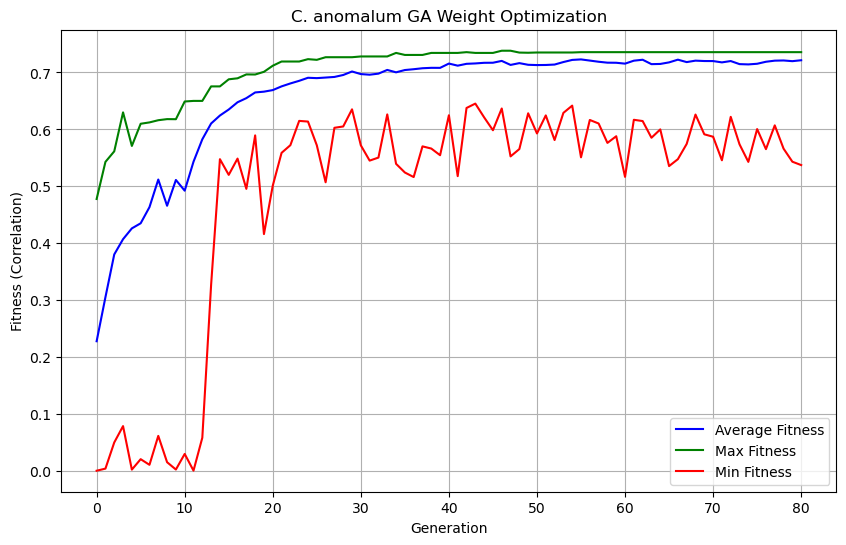

In [201]:
plot_ga_log(logbook, title="C. anomalum GA Weight Optimization")

In [202]:
for name, w in zip(FEATURE_NAMES, c_anomalum_weights):
    print(f"{name}: {w:.4f}")

avg_Depth: -0.8963
pf_Pool: 0.2218
pf_Riffle: 0.8930
pb_Mud: -0.3661
pb_SmGravel: 0.6448
pb_LgGravel: 0.2570
avgMonthFlow_cfs: 0.2622
CV_flow: 1.3426
pf_Run: 0.1799
pb_Boulder: 0.7033
pb_Sand: 0.6715
pft_Macrophytes: -0.1799
pft_Wood: -0.4641
maxMonthFlow_cfs: 0.7622
minMonthFlow_cfs: 0.0249
upstreamCumDA_km2: 0.0996
slopePercent: -0.0097


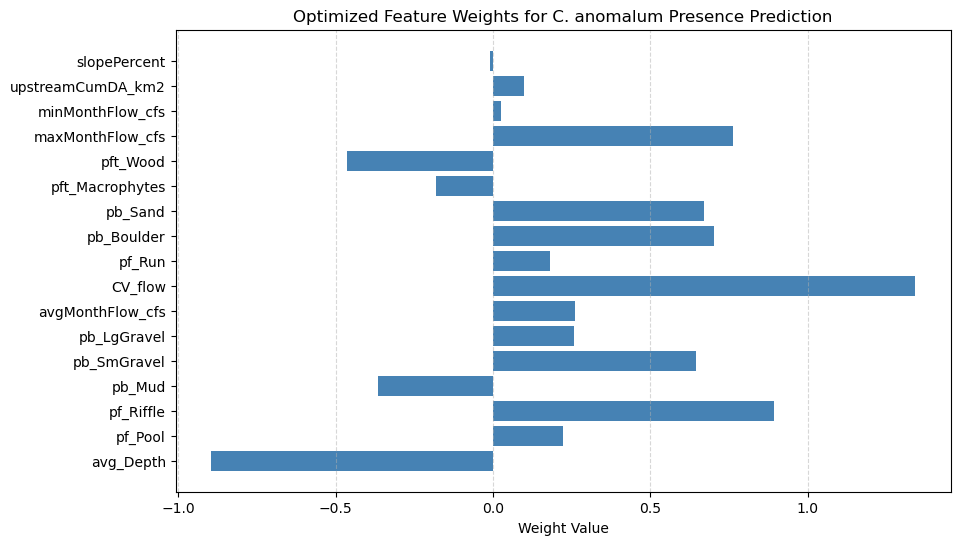

In [203]:
plt.figure(figsize=(10,6))
plt.barh(FEATURE_NAMES, c_anomalum_weights, color="steelblue")
plt.xlabel("Weight Value")
plt.title("Optimized Feature Weights for C. anomalum Presence Prediction")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

<h3>Genetic Algorithm for Optimizing Feature Weights</h3>

>We use a Genetic Algorithm (GA) to evolve a vector of feature weights that
maximizes the correlation between a weighted combination of environmental
metrics and the binary presence of *Campostoma anomalum*. Each individual
in the GA population represents one possible set of weights. The fitness
function applies these weights to the feature matrix and computes the
Spearman correlation with the presence vector. The GA then evolves the
weights through selection, crossover, and mutation to maximize this
correlation. The final result is an optimized set of feature weights that
indicate which environmental metrics best predict species presence.

<hr/>

In [204]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def evaluate_weights(weights_raw, X, y):
    """
    Fitness:
    - Convert raw weights to positive, normalized weights via softmax
    - Apply normalized weights to features
    - Compute Spearman correlation with presence
    - Return absolute correlation (maximize)
    """
    weights = softmax(np.array(weights_raw))  # normalized, sum to 1
    weighted_sum = np.dot(X, weights)
    corr, _ = spearmanr(weighted_sum, y)
    return (abs(corr),)


In [205]:
def run_ga_weight_optimizer(X, y, n_generations=60, pop_size=120):
    n_features = X.shape[1]

    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_float", np.random.uniform, -1, 1)
    toolbox.register("individual", tools.initRepeat,
                     creator.Individual, toolbox.attr_float, n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    toolbox.register("evaluate", evaluate_weights, X=X, y=y)
    toolbox.register("mate", tools.cxBlend, alpha=0.5)
    toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.3, indpb=0.2)
    toolbox.register("select", tools.selTournament, tournsize=3)

    pop = toolbox.population(pop_size)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    stats.register("min", np.min)
    stats.register("std", np.std)

    pop, logbook = algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.5, mutpb=0.3,
        ngen=n_generations,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    return np.array(hof[0]), logbook


In [ ]:
best_raw, softmax_logbook = run_ga_weight_optimizer(
    X=scaled_df[FEATURE_NAMES].values,
    y=scaled_df['C_anomalum_binary'].values,
    n_generations=80,
    pop_size=100
)

c_anomalum_percent_weights = softmax(best_raw)  # normalized, sum to 1


c:\Users\Korbin\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\Korbin\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg     	max     	min	std     
0  	100   	0.146626	0.341292	0  	0.087874
1  	65    	0.209614	0.393133	0.0172806	0.0746135
2  	58    	0.271737	0.423375	0.0734425	0.0679885
3  	75    	0.31118 	0.492497	0.0604821	0.0794824
4  	70    	0.370107	0.492497	0.0907231	0.0653616
5  	59    	0.407044	0.514098	0.29377  	0.0472324
6  	72    	0.434996	0.514098	0.29809  	0.0445696
7  	65    	0.462645	0.514098	0.237608 	0.037038 
8  	63    	0.484893	0.518418	0.388813 	0.020246 
9  	59    	0.495219	0.527058	0.406094 	0.0186083
10 	64    	0.50455 	0.527058	0.432015 	0.0141487
11 	67    	0.513752	0.540019	0.453616 	0.0132549
12 	58    	0.519109	0.540019	0.397454 	0.0161959
13 	70    	0.524552	0.548659	0.488177 	0.00972139
14 	66    	0.527922	0.548659	0.501137 	0.00942545
15 	56    	0.532242	0.548659	0.501137 	0.0083324 
16 	67    	0.534575	0.561619	0.501137 	0.00967212
17 	70    	0.535742	0.552979	0.496817 	0.00986083
18 	63    	0.540235	0.565939	0.496817 	0.0103571 
19 	49    	0.543647	0.5789  

In [207]:
for name, w in zip(FEATURE_NAMES, c_anomalum_percent_weights):
    print(f"{name}: {w*100:.4f}%")

print("Sum of weights:", c_anomalum_percent_weights.sum())

avg_Depth: 1.0755%
pf_Pool: 0.2033%
pf_Riffle: 28.5477%
pb_Mud: 0.4200%
pb_SmGravel: 13.3003%
pb_LgGravel: 5.6982%
avgMonthFlow_cfs: 4.2520%
CV_flow: 21.3305%
pf_Run: 11.5442%
pb_Boulder: 1.7855%
pb_Sand: 0.6181%
pft_Macrophytes: 2.5146%
pft_Wood: 0.3865%
maxMonthFlow_cfs: 0.7316%
minMonthFlow_cfs: 0.8686%
upstreamCumDA_km2: 4.1626%
slopePercent: 2.5607%
Sum of weights: 0.9999999999999999


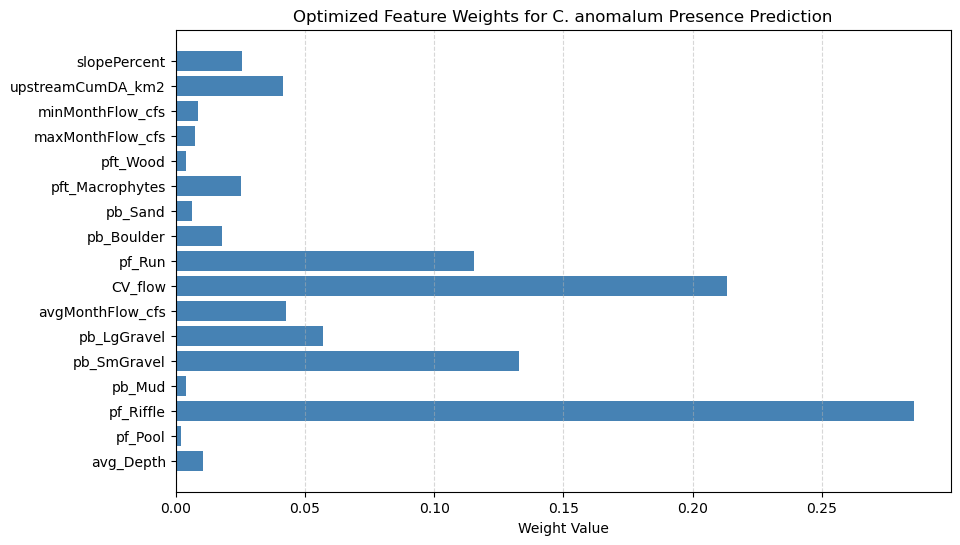

In [208]:
plt.figure(figsize=(10,6))
plt.barh(FEATURE_NAMES, c_anomalum_percent_weights, color="steelblue")
plt.xlabel("Weight Value")
plt.title("Optimized Feature Weights for C. anomalum Presence Prediction")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

<h3>Normalized, Ecologically Interpretable GA Weights</h3>

>To make the genetic algorithm’s feature weights ecologically interpretable,
we treat them as a probability distribution over environmental metrics.
Rather than using raw signed coefficients, we evolve unconstrained weights
and then transform them with a softmax function inside the fitness
evaluation. This ensures that all weights are non‑negative and sum to 1,
so each weight can be interpreted as the relative importance of that
metric for predicting *Campostoma anomalum* presence. The GA then
optimizes this normalized weight vector to maximize the Spearman
correlation between the weighted combination of metrics and the binary
presence data.


> Now I will create a vector that is our "suitability score" created by our best weights. 

> We will use this later for our prediction models.

In [ ]:
c_anomalum_suit = np.dot(scaled_df[FEATURE_NAMES].values, c_anomalum_weights)

print("Suitability Scores (first 10):", c_anomalum_suit[:10])
print(type(c_anomalum_suit))

Suitability Scores (first 10): [ 0.89483951  0.67396892 -0.12260143  1.84396265  0.51970447  0.41156771
  1.95872103  0.02503387  1.34009134  0.75413554]
<class 'numpy.ndarray'>


<hr/>
<br/>

<h4>Feature Trend Line Fit</h4>

> Starting with our C. Anomalum's population relation with percent bottom.

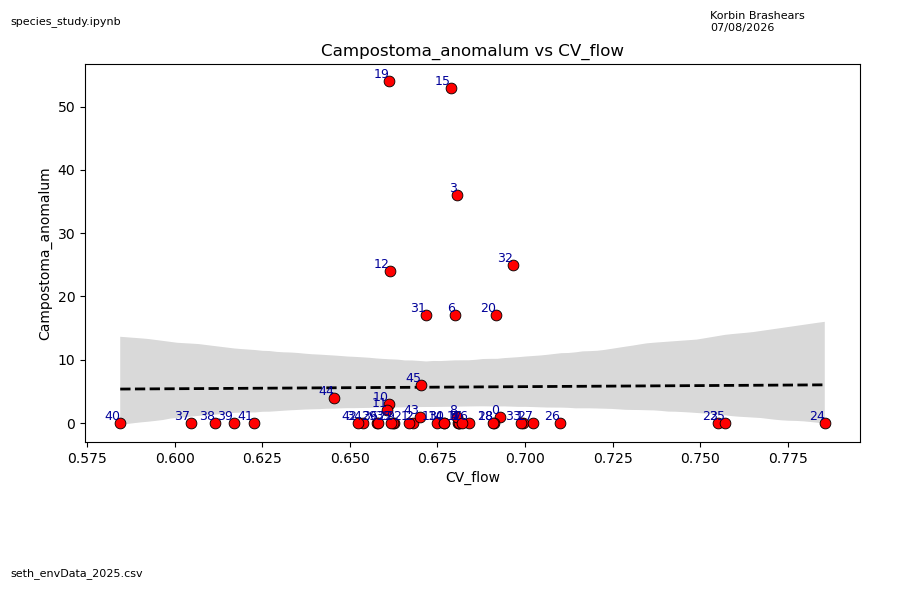

In [210]:
scatter_trendLine_plotter(s_ed['CV_flow'], s_fcd['Campostoma_anomalum'])

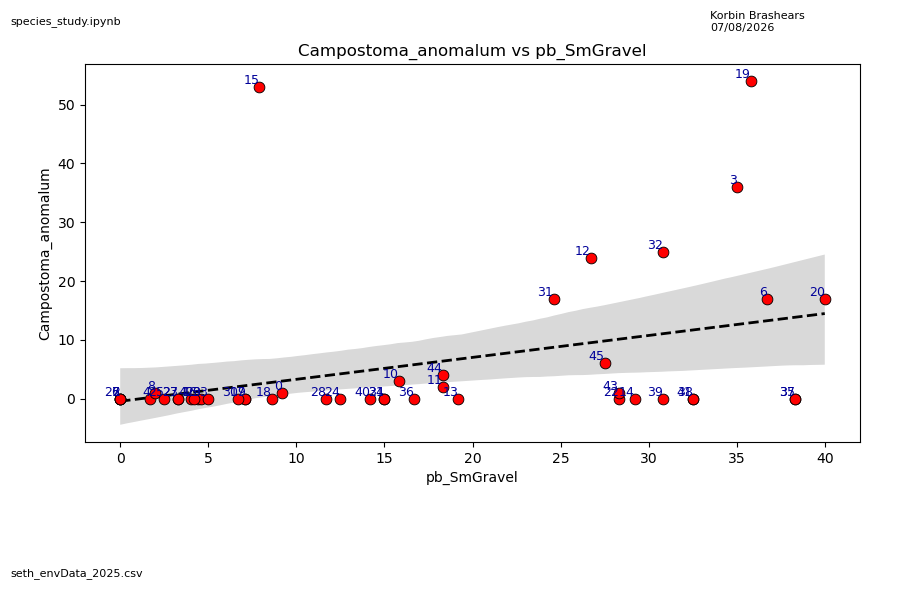

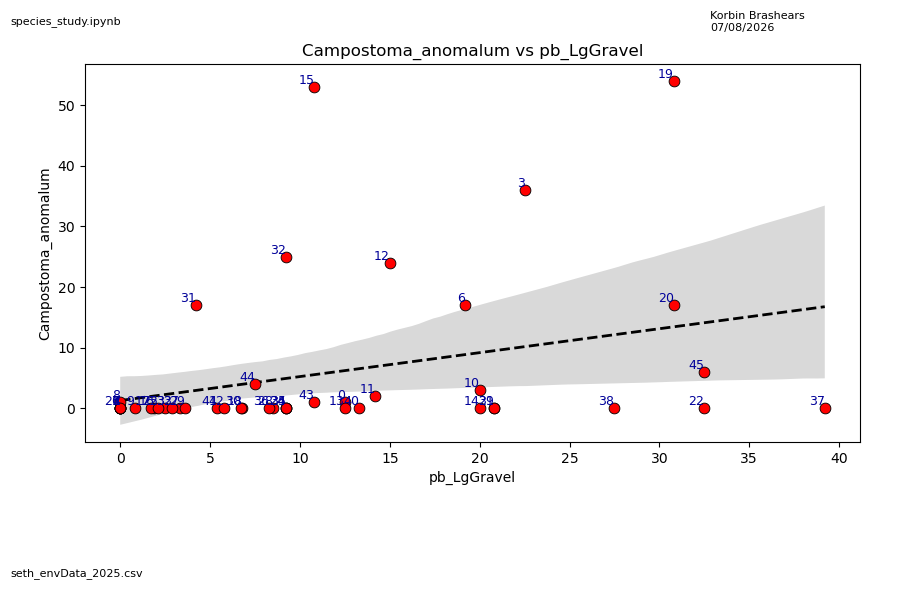

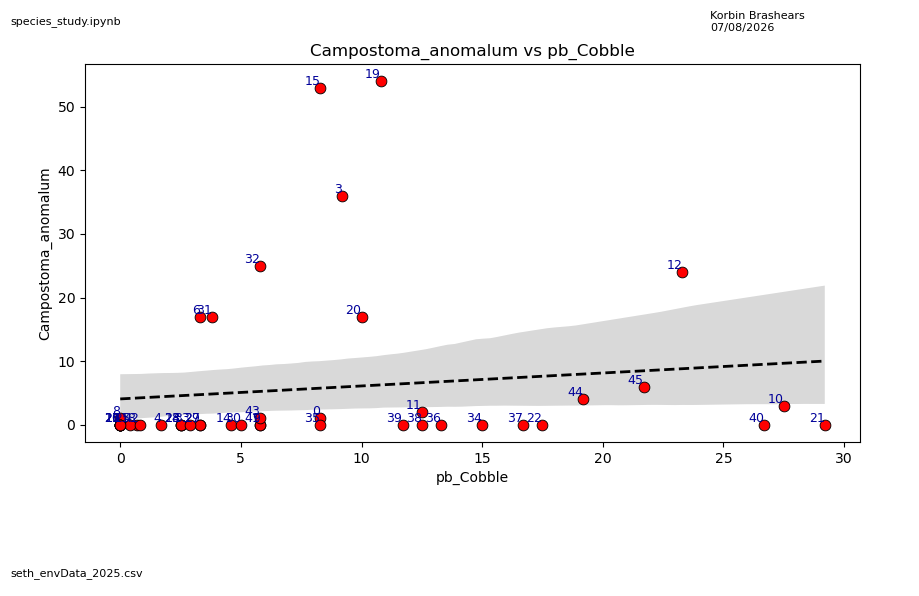

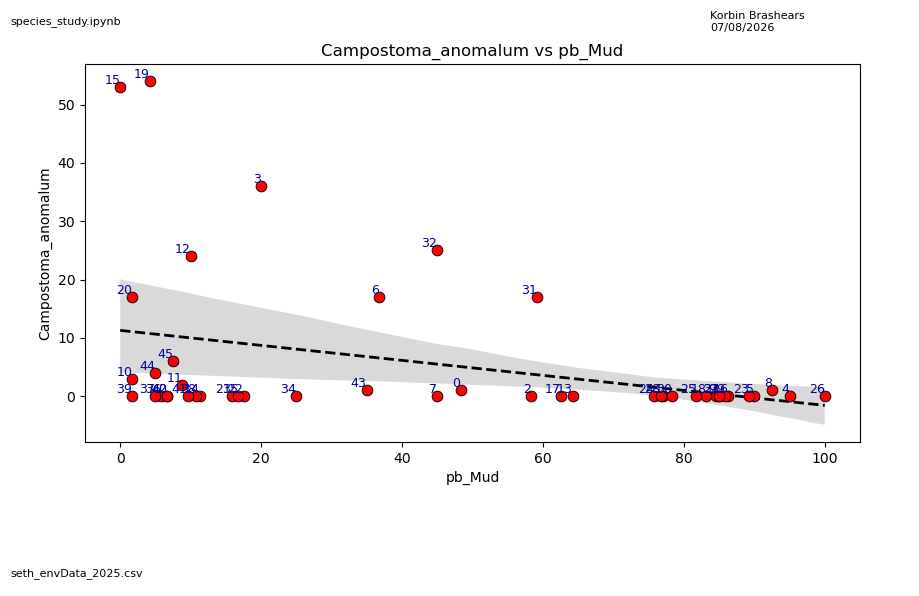

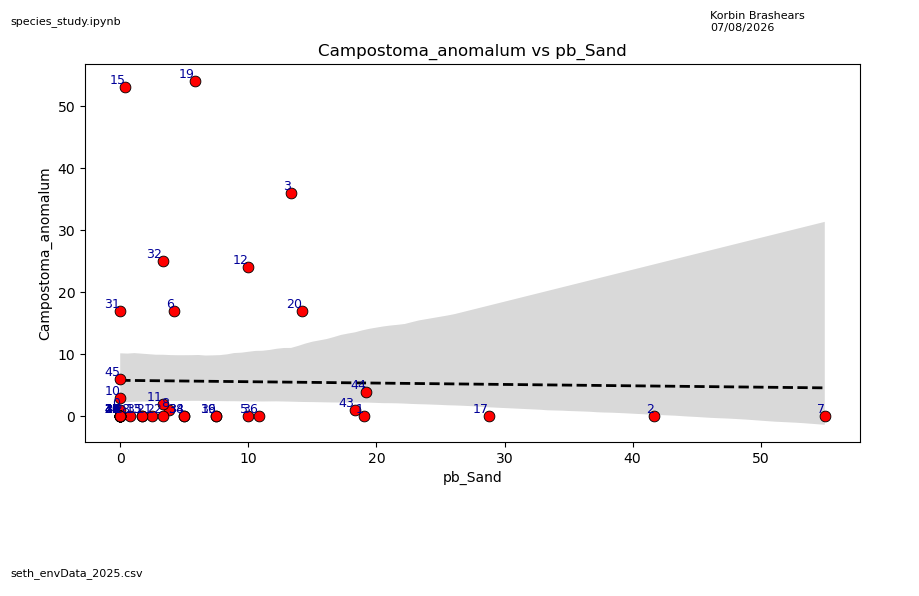

In [211]:
scatter_trendLine_plotter(s_ed['pb_SmGravel'], s_fcd['Campostoma_anomalum'])

scatter_trendLine_plotter(s_ed['pb_LgGravel'], s_fcd['Campostoma_anomalum'])

scatter_trendLine_plotter(s_ed['pb_Cobble'], s_fcd['Campostoma_anomalum'])

scatter_trendLine_plotter(s_ed['pb_Mud'], s_fcd['Campostoma_anomalum'])

scatter_trendLine_plotter(s_ed['pb_Sand'], s_fcd['Campostoma_anomalum'])

> Next we will look at C. Anomalum's population relation with site_N.sunshine.

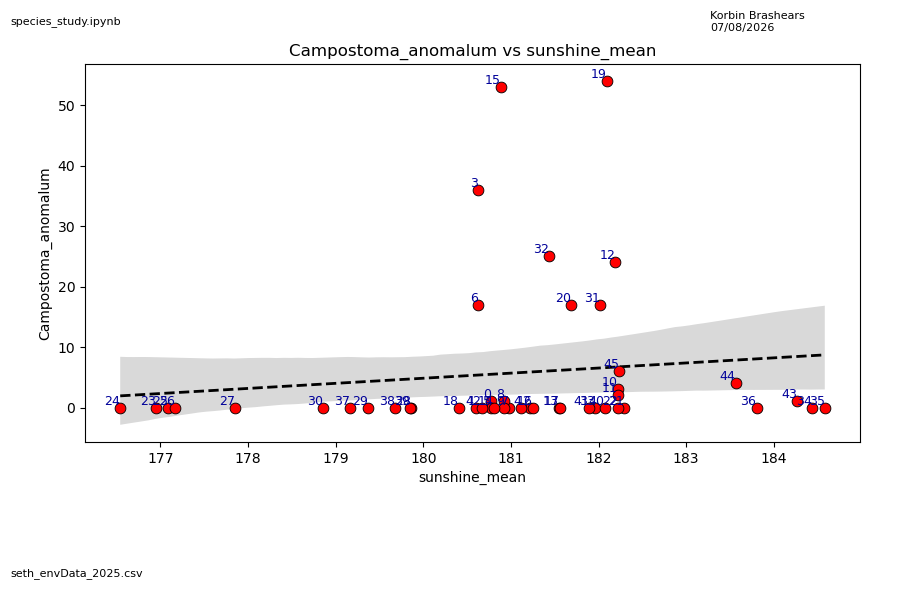

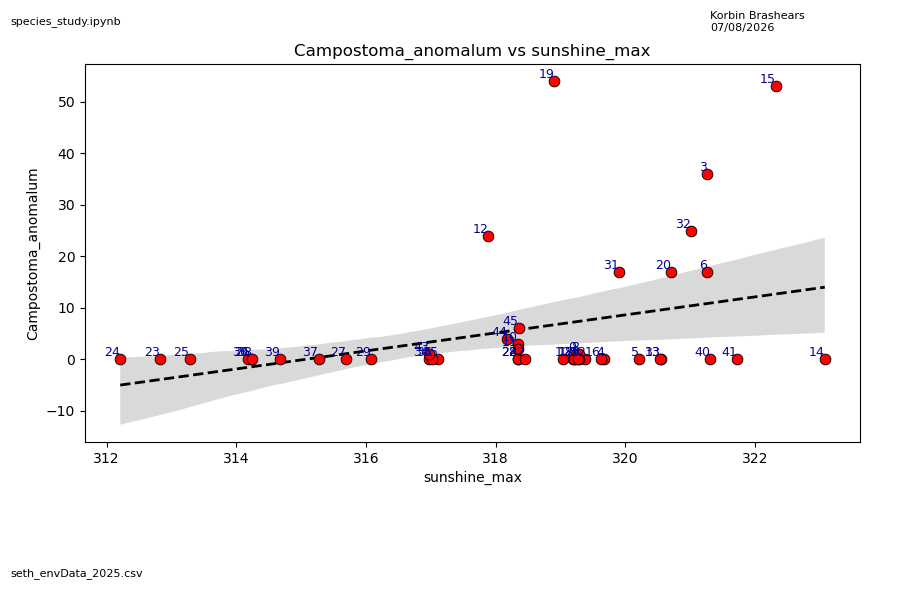

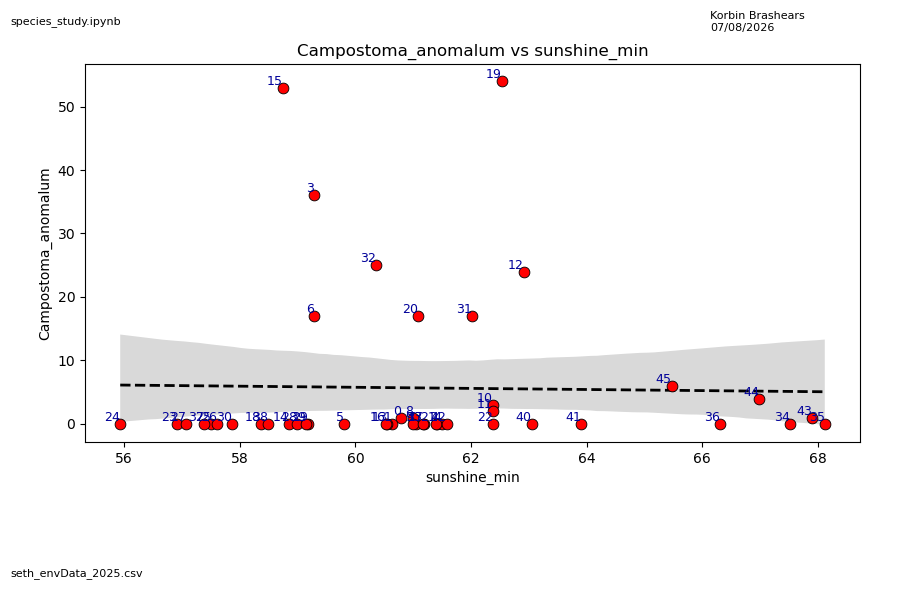

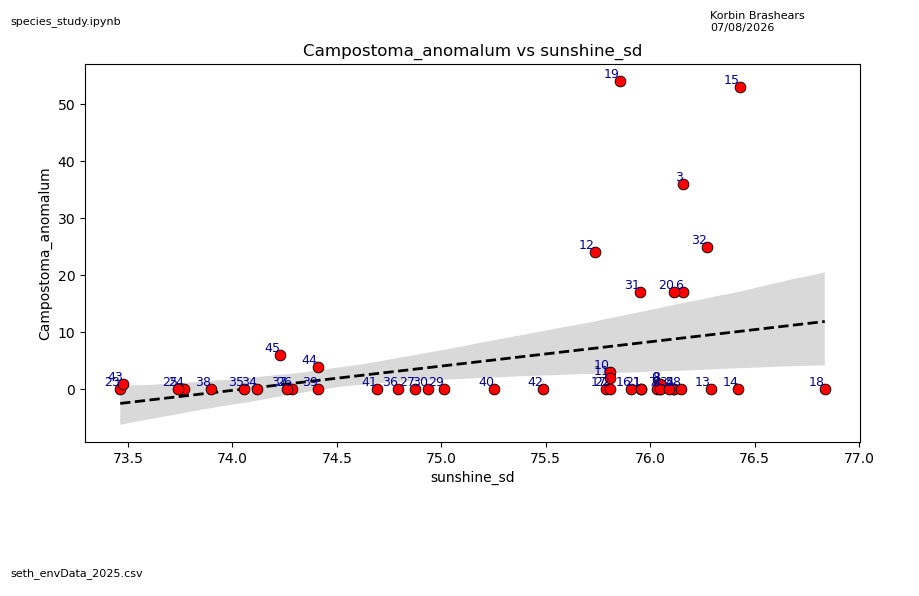

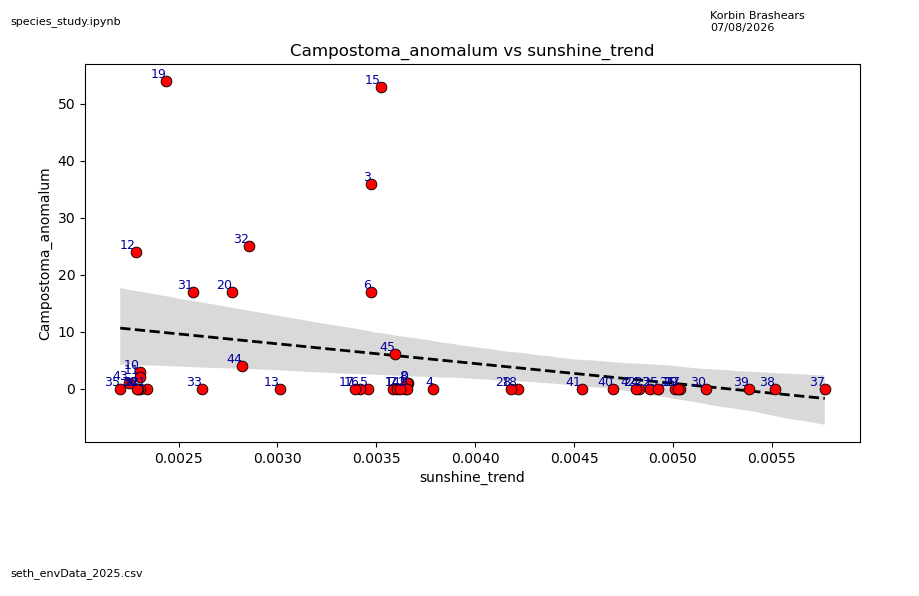

In [212]:
scatter_trendLine_plotter(g_10dts_m['sunshine_mean'], s_fcd['Campostoma_anomalum'])

scatter_trendLine_plotter(g_10dts_m['sunshine_max'], s_fcd['Campostoma_anomalum'])

scatter_trendLine_plotter(g_10dts_m['sunshine_min'], s_fcd['Campostoma_anomalum'])

scatter_trendLine_plotter(g_10dts_m['sunshine_sd'], s_fcd['Campostoma_anomalum'])

scatter_trendLine_plotter(g_10dts_m['sunshine_trend'], s_fcd['Campostoma_anomalum'])

> Next we will look at C. Anomalum's population relation with pft_Macrophytes and pft_Wood.

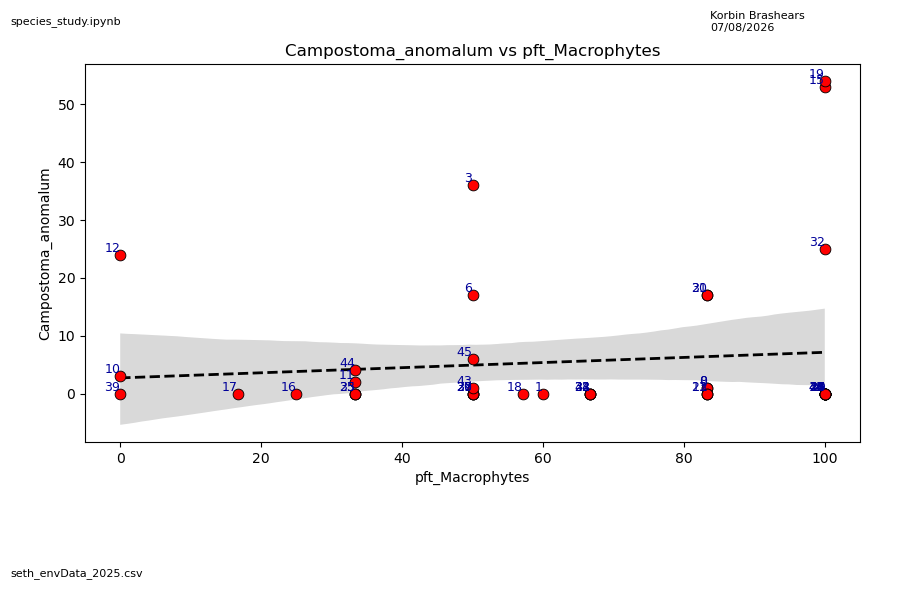

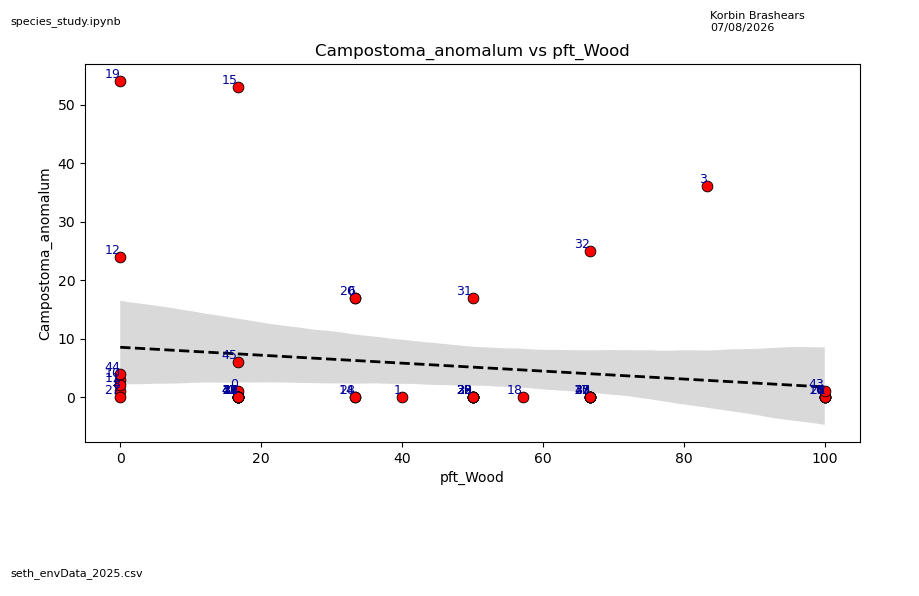

In [213]:
scatter_trendLine_plotter(s_ed['pft_Macrophytes'], s_fcd['Campostoma_anomalum'])
scatter_trendLine_plotter(s_ed['pft_Wood'], s_fcd['Campostoma_anomalum'])

> Next we will look at C. Anomalum's population relation with the percent flow metrics (pf_Riffle, pf_Run, pf_Pool).

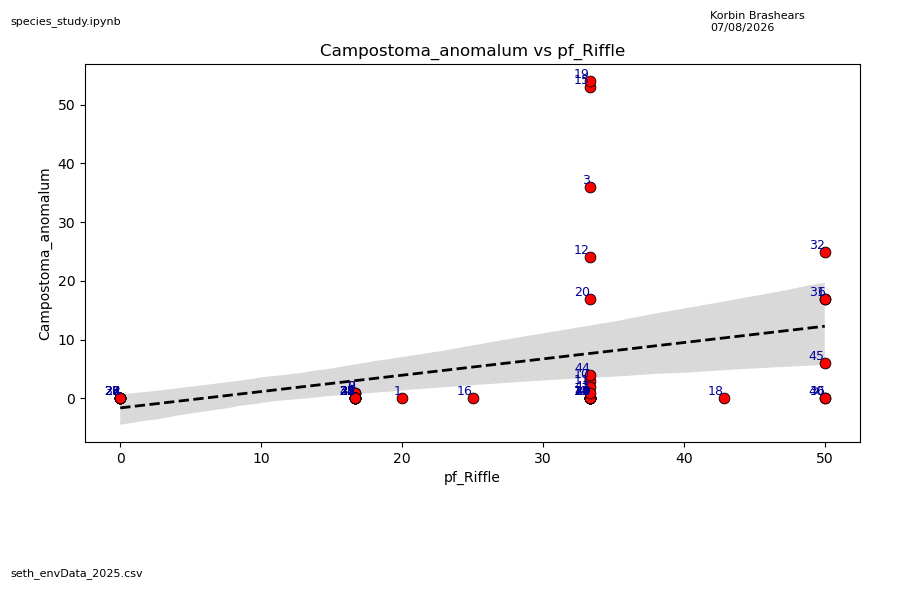

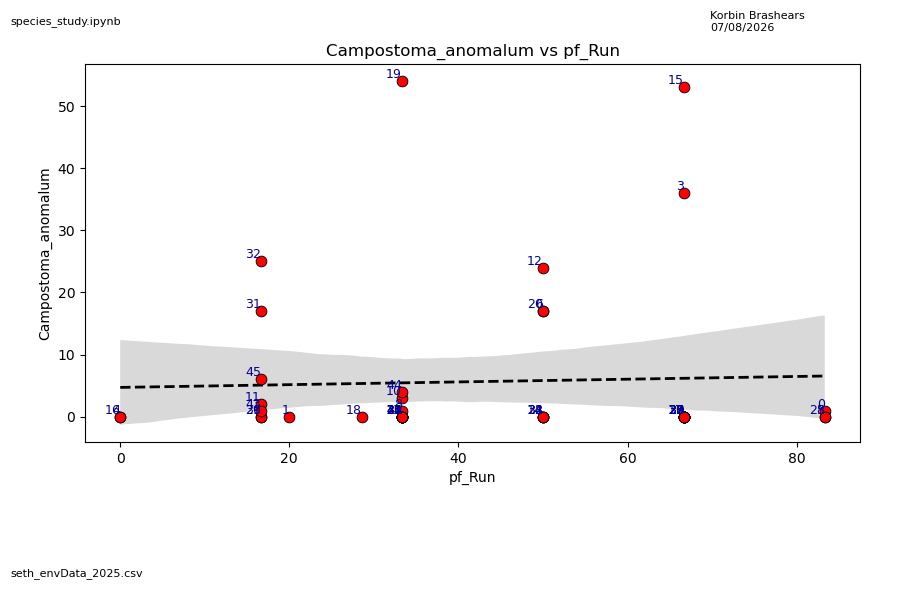

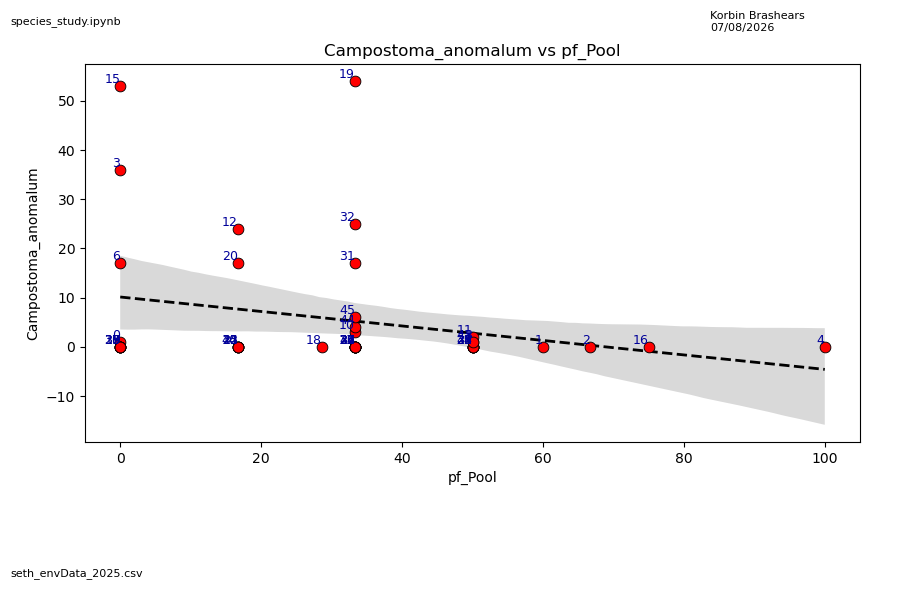

In [214]:
scatter_trendLine_plotter(s_ed['pf_Riffle'], s_fcd['Campostoma_anomalum'])
scatter_trendLine_plotter(s_ed['pf_Run'], s_fcd['Campostoma_anomalum'])
scatter_trendLine_plotter(s_ed['pf_Pool'], s_fcd['Campostoma_anomalum'])

<hr/>
<br/>

#### <a id='toc1_4_1_1_'></a>[Ensemble and Classifier Models](#toc0_)

> Now we will use these metrics to see 

<h3> Creating Our Models</h3>

In [ ]:
df = scaled_df[['C_anomalum_count', 'C_anomalum_binary']].copy()
df['suitability'] = c_anomalum_suit

df.head()

,C_anomalum_count,C_anomalum_binary,suitability
0,1.0,0,0.894840
1,0.0,0,0.673969
2,0.0,0,-0.122601
3,36.0,1,1.843963
4,0.0,0,0.519704


In [234]:
X = df['suitability']
y = df['C_anomalum_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic"
    )
model.fit(X_train, y_train)
y_pred_prob = model.predict_proba(X_test)[:, 1]

In [240]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

y_pred = (y_pred_prob >= 0.5).astype(int)
auc = roc_auc_score(y_test, y_pred_prob)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"auc: {auc}")
print(f"acc: {acc}")
print(f"f1: {f1}")

auc: 1.0
acc: 1.0
f1: 1.0


In [241]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 1. Select predictors & target
# -----------------------------
X = df['suitability']        # or df[predictor_columns]
y = df['C_anomalum_count']   # abundance instead of binary

# -----------------------------
# 2. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBRegressor expects 2D input
X_train = np.array(X_train).reshape(-1, 1)
X_test  = np.array(X_test).reshape(-1, 1)

# -----------------------------
# 3. Train the model
# -----------------------------
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

model.fit(X_train, y_train)

# -----------------------------
# 4. Predict
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 5. Evaluate
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE:  {mae}")
print(f"R²:   {r2}")


RMSE: 10.819764463328301
MAE:  5.09939008008223
R²:   0.2017231296153975


In [5]:
s_erd = pd.read_csv("../data/seth_ecoRegionData_2025.csv")

In [6]:
e_radiosum_df = s_fcd[s_fcd['Etheostoma_radiosum'] > 10]

tx_sites, ok_sites = e_radiosum_df[e_radiosum_df['State'] == 1].index, e_radiosum_df[e_radiosum_df['State'] == 2].index

print(e_radiosum_df['State'].value_counts())
print('===============================')
print(f'TX States: {tx_sites}')
print('===============================')
for idx in tx_sites:
    print(f'{s_erd.loc[idx, 'Lat']}, {s_erd.loc[idx, 'Long']},blue, square')
print('===============================')
print(f'OK States: {ok_sites}')
print('===============================')
for idx in ok_sites:
    print(f'{s_erd.loc[idx, 'Lat']}, {s_erd.loc[idx, 'Long']},red, marker')
print('===============================')

State
2    9
1    4
Name: count, dtype: int64
TX States: Index([11, 12, 21, 22], dtype='int64')
33.791701, -96.567376,blue, square
33.791936, -96.530699,blue, square
33.81, -96.678,blue, square
33.784, -96.594,blue, square
OK States: Index([36, 37, 38, 39, 40, 41, 42, 44, 45], dtype='int64')
34.085386, -96.731884,red, marker
34.061, -94.476,red, marker
34.064, -94.645,red, marker
34.076, -94.852,red, marker
34.528, -95.489,red, marker
34.345, -95.634,red, marker
34.02, -95.361,red, marker
34.329359, -96.419486,red, marker
34.485, -95.983,red, marker


In [ ]:
site_coords = [(s_erd.loc[idx, "Lat"], s_erd.loc[idx, 'Long']) for idx in s_erd.index]

print(site_coords)

[(np.float64(33.741217), np.float64(-95.927376)), (np.float64(33.717896), np.float64(-95.911323)), (np.float64(33.747466), np.float64(-96.019146)), (np.float64(33.554952), np.float64(-96.169601)), (np.float64(33.823594), np.float64(-95.861067)), (np.float64(33.603081), np.float64(-96.139938)), (np.float64(33.540313), np.float64(-96.179298)), (np.float64(33.722903), np.float64(-95.987208)), (np.float64(33.744233), np.float64(-95.960811)), (np.float64(33.733841), np.float64(-95.968054)), (np.float64(33.807445), np.float64(-96.563396)), (np.float64(33.791701), np.float64(-96.567376)), (np.float64(33.791936), np.float64(-96.530699)), (np.float64(33.636749), np.float64(-96.435176)), (np.float64(33.48), np.float64(-96.341)), (np.float64(33.496), np.float64(-96.388)), (np.float64(33.642), np.float64(-96.181)), (np.float64(33.664), np.float64(-96.181)), (np.float64(33.871), np.float64(-95.544)), (np.float64(33.756), np.float64(-96.521)), (np.float64(33.609), np.float64(-96.605)), (np.float64(3